# CML vs BIDS Comparison

Using `bids_validation` package with `CMLBIDSReader`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import os
import numpy as np
import pandas as pd
import cmlreaders as cml
import matplotlib.pyplot as plt
%matplotlib inline

from cmldask import CMLDask
from dask.distributed import wait, progress

from eeg_validation import (
    EventsPipeline,
    RawSignalPipeline,
    EpochedPipeline,
    MontagePipeline,
    DigitalSignalPipeline
)
from eeg_validation.io import load_and_concat
from eeg_validation.plotting import plot_comparison_results

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
import sys
sys.path.append("/home1/zrentala/bidsreader")
from bidsreader import CMLBIDSReader

## 1. Configuration

In [2]:
# ---- Shared settings ----
REL_START = 200      # ms
REL_STOP  = 500     # ms
BUFFER_MS = 500     # ms
tmin = -BUFFER_MS
tmax = REL_STOP + BUFFER_MS

MAX_SUBJECTS = 10
SUBJECTS_TO_EXCLUDE = {"LTP001", "LTP9992", "LTP9993"}

# Set to True to skip sessions whose output CSVs already exist
SKIP_IF_EXISTS = True


In [3]:


def load_dfs(file_categories, final_dir):
    """Load aggregated CSVs from the final directory for each category."""
    dfs = {}
    for cat in file_categories:
        path = os.path.join(final_dir, f"{cat}_all.csv")
        if os.path.exists(path):
            try: 
                dfs[cat] = pd.read_csv(path)
                print(f"{cat}: loaded {len(dfs[cat])} rows from {path}")
            except:
                print(f"Couldn't load {cat}")
        else:
            print(f"Skipping {cat} (file not found: {path})")
    return dfs


def get_completed_sessions(final_dir, summary_files=None):
    """Return set of (subject, session) tuples that appear in ALL *summary* files."""
    import glob
    if summary_files is not None:
        summary_files = [os.path.join(final_dir, f) for f in summary_files]
    else:
        summary_files = sorted(glob.glob(os.path.join(final_dir, "*summary*_all.csv")))
    if not summary_files:
        return set()

    sets = []
    for path in summary_files:
        df = pd.read_csv(path, usecols=["subject", "session"]).dropna(subset=["subject", "session"])
        pairs = set(zip(df["subject"], df["session"].astype(int)))
        sets.append(pairs)
        print(f"  {os.path.basename(path)}: {len(pairs)} (subject, session) pairs")

    completed = sets[0]
    for s in sets[1:]:
        completed &= s
    print(f"  -> {len(completed)} sessions completed across all {len(summary_files)} summary files")
    return completed


In [4]:
import ast
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------- summary stats (computed once, passed into plots) ----------------

def expected_from_jobs(jobs_df):
    """Build the ground-truth n_subjects from a jobs DataFrame
    (e.g. df_ltp / df_ram from cml.get_data_index()), so n_subjects is
    constant across all plots in a pipeline regardless of which sessions
    happen to appear in each summary df."""
    return {
        "n_subjects": int(jobs_df["subject"].nunique()),
        "n_comparisons": int(len(jobs_df)),  # informational; not used as a denom
    }




def _padded_mean_se(values, target_n):
    """Mean and SE assuming any missing entries (target_n - len(values))
    are 0 — i.e. missing subjects/files/epochs contribute no difference."""
    arr = np.asarray(list(values), dtype=float)
    n_missing = max(0, int(target_n) - len(arr))
    if n_missing > 0:
        arr = np.concatenate([arr, np.zeros(n_missing)])
    if len(arr) == 0:
        return 0.0, 0.0
    mean = float(arr.mean())
    se = float(arr.std(ddof=1) / np.sqrt(len(arr))) if len(arr) > 1 else 0.0
    return mean, se


def _expected_n_comp(df, expected):
    """Row-level denominator that pads missing rows with 0:
    use len(df) when df has at least as many rows as expected (fan-out
    case), otherwise use expected n_comparisons (missing-rows case)."""
    if expected is None:
        return int(len(df))
    return int(max(len(df), int(expected.get("n_comparisons", 0))))

def _resolve_denoms(df, expected):
    """n_subjects: from expected jobs df (constant per pipeline).
    n_comparisons: max(len(df), expected n_comparisons) — pads missing
    rows with 0 so denominators stay the truth, but also handles
    fan-out dfs (epoch event_types) where len(df) > # sessions."""
    n_comp = _expected_n_comp(df, expected)
    if expected is not None:
        n_subs = int(expected["n_subjects"])
    else:
        n_subs = int(df["subject"].nunique())
    return n_subs, n_comp


def signal_summary_stats(df, expected=None):
    n_subs, n_comp = _resolve_denoms(df, expected)
    bad = df.query("n_close_diff_channels > 0")
    n_subs_close = int(bad["subject"].nunique())
    n_comp_close = int(len(bad))
    # Per-subject mean: each subject's per-row mean, padded with 0 for
    # subjects expected but absent from df.
    per_sub_means = df.groupby("subject")["n_close_diff_channels"].mean().values
    avg_per_sub, _ = _padded_mean_se(per_sub_means, n_subs)
    # Per-row mean: pad missing rows with 0 (n_comp already padded).
    avg_per_row, _ = _padded_mean_se(df["n_close_diff_channels"].values, n_comp)
    mse_mean, mse_se = _padded_mean_se(df["mse"].values, n_comp)
    # MSE restricted to rows with at least one channel above tolerance
    mse_mean_diff = float(bad["mse"].mean()) if len(bad) else 0.0
    mse_se_diff = float(bad["mse"].sem()) if len(bad) > 1 else 0.0
    return {
        "kind": "signal",
        "n_subjects": n_subs,
        "n_comparisons": n_comp,
        "n_subs_close": n_subs_close,
        "n_comp_close": n_comp_close,
        "pct_subs_close": (n_subs_close / n_subs) if n_subs else 0,
        "pct_comp_close": (n_comp_close / n_comp) if n_comp else 0,
        "avg_close_per_sub": avg_per_sub,
        "avg_close_per_comp": avg_per_row,
        "mse_mean": mse_mean,
        "mse_se": mse_se,
        "mse_mean_diff": mse_mean_diff,
        "mse_se_diff": mse_se_diff,
    }


def time_summary_stats(df, expected=None):
    n_subs, n_comp = _resolve_denoms(df, expected)
    bad = df.query("n_close_time_diff > 0")
    n_subs_close = int(bad["subject"].nunique())
    n_comp_close = int(len(bad))
    per_sub_means = df.groupby("subject")["n_close_time_diff"].mean().values
    avg_per_sub, _ = _padded_mean_se(per_sub_means, n_subs)
    avg_per_row, _ = _padded_mean_se(df["n_close_time_diff"].values, n_comp)
    mse_mean, mse_se = _padded_mean_se(df["mse_time"].values, n_comp)
    mse_mean_diff = float(bad["mse_time"].mean()) if len(bad) else 0.0
    mse_se_diff = float(bad["mse_time"].sem()) if len(bad) > 1 else 0.0
    return {
        "kind": "time",
        "n_subjects": n_subs,
        "n_comparisons": n_comp,
        "n_subs_close": n_subs_close,
        "n_comp_close": n_comp_close,
        "pct_subs_close": (n_subs_close / n_subs) if n_subs else 0,
        "pct_comp_close": (n_comp_close / n_comp) if n_comp else 0,
        "avg_close_per_sub": avg_per_sub,
        "avg_close_per_comp": avg_per_row,
        "mse_mean": mse_mean,
        "mse_se": mse_se,
        "mse_mean_diff": mse_mean_diff,
        "mse_se_diff": mse_se_diff,
    }


def behavior_summary_stats(df, expected=None):
    n_subs, n_comp = _resolve_denoms(df, expected)
    bad = df.query("n_differing_columns > 0")
    n_subs_diff = int(bad["subject"].nunique())
    n_comp_diff = int(len(bad))
    per_sub_means = df.groupby("subject")["n_differing_columns"].mean().values
    avg_per_sub, _ = _padded_mean_se(per_sub_means, n_subs)
    avg_per_row, _ = _padded_mean_se(df["n_differing_columns"].values, n_comp)
    return {
        "kind": "behavior",
        "n_subjects": n_subs,
        "n_comparisons": n_comp,
        "n_subs_diff": n_subs_diff,
        "n_comp_diff": n_comp_diff,
        "pct_subs_diff": (n_subs_diff / n_subs) if n_subs else 0,
        "pct_comp_diff": (n_comp_diff / n_comp) if n_comp else 0,
        "avg_diff_cols_per_sub": avg_per_sub,
        "avg_diff_cols_per_comp": avg_per_row,
    }


def montage_summary_stats(df, expected=None):
    n_rows = len(df)
    if expected is not None:
        n_subs = int(expected["n_subjects"])
    else:
        n_subs = int(df["subject"].nunique())
    contacts = int(df["contacts_skipped"].astype(bool).sum()) if "contacts_skipped" in df.columns else 0
    pairs = int(df["pairs_skipped"].astype(bool).sum()) if "pairs_skipped" in df.columns else 0
    return {
        "kind": "montage",
        "n_subjects": n_subs,
        "n_rows": n_rows,
        "n_contacts_skipped": contacts,
        "n_pairs_skipped": pairs,
        "pct_contacts_skipped": (contacts / n_rows) if n_rows else 0,
        "pct_pairs_skipped": (pairs / n_rows) if n_rows else 0,
    }


# ---------------- units & titles ----------------

# What each row in a summary df represents.
_DF_UNIT = {
    "df_raw_summary": "files",
    "df_raw_time": "files",
    "df_epoch_summary": "epochs",
    "df_epoch_time": "epochs",
    "df_time": "files",
    "df_behavior_summary": "behavior files",
    "df_contacts_summary": "montage files",
    "df_pairs_summary": "montage files",
    "df_montage_summary": "montage files",
}


def _unit_for(df_key, default="comparisons"):
    return _DF_UNIT.get(df_key, default)


def _singular(unit):
    return unit[:-1] if unit.endswith("s") else unit


def _basic_title(name, n_subjects, n_units, unit):
    return f"{name}\ncomparing {int(n_units)} {unit} across {int(n_subjects)} subjects"


# ---------------- saving ----------------

def _save_fig(fig, save_dir, filename):
    if save_dir is None:
        return
    p = Path(save_dir)
    p.mkdir(parents=True, exist_ok=True)
    fig.savefig(p / filename, dpi=150, bbox_inches="tight")


def save_summary_stats(stats_by_df, save_dir, filename="summary_stats.json"):
    if save_dir is None:
        return
    p = Path(save_dir)
    p.mkdir(parents=True, exist_ok=True)
    with open(p / filename, "w") as f:
        json.dump(stats_by_df, f, indent=2, default=str)


# ---------------- generic 2-panel counts/pcts plot ----------------

def _plot_counts_pcts(stats, name, unit,
                      total_keys, diff_keys, pct_keys,
                      save_dir=None, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = _basic_title(name, stats["n_subjects"], stats["n_comparisons"], unit)
    count_labels = ["subjects", unit]
    pct_labels = ["% subjects", f"% {unit}"]

    # counts panel
    ax = axes[0]
    x = np.arange(len(count_labels))
    w = 0.38
    totals = [stats[k] for k in total_keys]
    diffs = [stats[k] for k in diff_keys]
    b1 = ax.bar(x - w / 2, totals, w, label="total", color="lightgray")
    b2 = ax.bar(x + w / 2, diffs, w, label="with diff > rtol", color="C3")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    f"{int(b.get_height())}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(count_labels)
    ax.set_ylabel("count")
    ax.set_title(title, fontsize=10)
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    # pcts panel
    ax = axes[1]
    vals = [stats[k] * 100 for k in pct_keys]
    bars = ax.bar(pct_labels, vals, color="C3")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("percent")
    ax.set_ylim(0, 105)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, save_dir, filename or f"{name}_summary.png")
    plt.show()
    return fig


def plot_signal_summary(stats, name="signal", unit="files", save_dir=None):
    return _plot_counts_pcts(
        stats, name, unit,
        total_keys=["n_subjects", "n_comparisons"],
        diff_keys=["n_subs_close", "n_comp_close"],
        pct_keys=["pct_subs_close", "pct_comp_close"],
        save_dir=save_dir, filename=f"{name}_signal_summary.png",
    )


def plot_time_summary(stats, name="time", unit="files", save_dir=None):
    return _plot_counts_pcts(
        stats, name, unit,
        total_keys=["n_subjects", "n_comparisons"],
        diff_keys=["n_subs_close", "n_comp_close"],
        pct_keys=["pct_subs_close", "pct_comp_close"],
        save_dir=save_dir, filename=f"{name}_time_summary.png",
    )


def plot_behavior_summary(stats, name="behavior", unit="files", save_dir=None):
    return _plot_counts_pcts(
        stats, name, unit,
        total_keys=["n_subjects", "n_comparisons"],
        diff_keys=["n_subs_diff", "n_comp_diff"],
        pct_keys=["pct_subs_diff", "pct_comp_diff"],
        save_dir=save_dir, filename=f"{name}_behavior_summary.png",
    )


def plot_montage_summary(stats, name="montage", unit="montage files", save_dir=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    cats = ["contacts_skipped", "pairs_skipped"]
    vals = [stats["n_contacts_skipped"], stats["n_pairs_skipped"]]
    bars = ax.bar(cats, vals, color="C3")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{int(v)}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel(f"# {unit}")
    ax.set_title(_basic_title(name, stats["n_subjects"], stats["n_rows"], unit), fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    _save_fig(fig, save_dir, f"{name}_montage_summary.png")
    plt.show()
    return fig


# ---------------- avg + MSE metric plots ----------------

def _plot_metrics(stats, name, unit, mse_label, avg_label_unit,
                  avg_sub_key, avg_comp_key, mse_mean_key, mse_se_key,
                  save_dir=None, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    title = _basic_title(name, stats["n_subjects"], stats["n_comparisons"], unit)

    # avg counts panel
    ax = axes[0]
    cats = ["avg / subject", f"avg / {_singular(unit)}"]
    vals = [stats[avg_sub_key], stats[avg_comp_key]]
    bars = ax.bar(cats, vals, color="C0")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel(avg_label_unit)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    # MSE panel with SE error bars: all rows (incl. zero-padded) vs only
    # rows with diff > rtol
    ax = axes[1]
    mse_all = stats[mse_mean_key]
    se_all = stats[mse_se_key]
    mse_diff = stats.get("mse_mean_diff", 0.0)
    se_diff = stats.get("mse_se_diff", 0.0)
    cats = ["all", "with diff > rtol"]
    means = [mse_all, mse_diff]
    ses = [se_all, se_diff]
    bars = ax.bar(cats, means, yerr=ses, capsize=8,
                  color=["lightgray", "C3"],
                  error_kw={"elinewidth": 1.5})
    for i, (b, m, e) in enumerate(zip(bars, means, ses)):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{m:.2e}\n\u00b1{e:.2e}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel(mse_label)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, save_dir, filename or f"{name}_metrics.png")
    plt.show()
    return fig


def plot_signal_metrics(stats, name="signal", unit="files", save_dir=None):
    return _plot_metrics(
        stats, name, unit,
        mse_label="MSE",
        avg_label_unit="# channels with diff > rtol",
        avg_sub_key="avg_close_per_sub",
        avg_comp_key="avg_close_per_comp",
        mse_mean_key="mse_mean", mse_se_key="mse_se",
        save_dir=save_dir, filename=f"{name}_signal_metrics.png",
    )


def plot_time_metrics(stats, name="time", unit="files", save_dir=None):
    return _plot_metrics(
        stats, name, unit,
        mse_label="MSE_time",
        avg_label_unit="# events with diff > rtol",
        avg_sub_key="avg_close_per_sub",
        avg_comp_key="avg_close_per_comp",
        mse_mean_key="mse_mean", mse_se_key="mse_se",
        save_dir=save_dir, filename=f"{name}_time_metrics.png",
    )


# ---------------- top-N items (channels / columns) ----------------

def _parse_listcol(cell):
    if isinstance(cell, list):
        return cell
    if pd.isna(cell):
        return []
    try:
        v = ast.literal_eval(cell)
        return list(v) if isinstance(v, (list, tuple)) else []
    except (ValueError, SyntaxError):
        return []


def _top_items(df, list_col, top_n=100):
    per_comp = Counter()
    sub_pairs = set()
    for sub, raw in zip(df["subject"], df[list_col]):
        items = _parse_listcol(raw)
        per_comp.update(items)
        for it in items:
            sub_pairs.add((sub, it))
    sub_counts = Counter()
    for (_, it) in sub_pairs:
        sub_counts[it] += 1
    s_comp = pd.Series(per_comp).sort_values(ascending=False).head(top_n)
    s_sub = pd.Series(sub_counts).sort_values(ascending=False).head(top_n)
    return s_comp, s_sub


def plot_top_items(df, list_col, name="df", top_n=100, item_label="channel",
                   save_dir=None, filename=None):
    if list_col not in df.columns:
        return None
    s_comp, s_sub = _top_items(df, list_col, top_n=top_n)
    if s_comp.empty and s_sub.empty:
        return None
    n_bars = max(len(s_comp), len(s_sub))
    shown_n = min(top_n, n_bars)
    # ~0.32" per bar plus a little headroom; clamp to a sensible range
    height = max(3.0, min(40.0, 1.5 + 0.32 * n_bars))
    fig, axes = plt.subplots(1, 2, figsize=(14, height))
    axes[0].barh(s_comp.index[::-1], s_comp.values[::-1], color="C0")
    axes[0].set_title(f"{name}: top {shown_n} {item_label}s by # comparisons")
    axes[0].set_xlabel(f"# comparisons with {item_label} diff")
    axes[0].grid(axis="x", alpha=0.3)
    axes[1].barh(s_sub.index[::-1], s_sub.values[::-1], color="C2")
    axes[1].set_title(f"{name}: top {shown_n} {item_label}s by # subjects")
    axes[1].set_xlabel(f"# subjects with {item_label} diff")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    _save_fig(fig, save_dir, filename or f"{name}_top_{item_label}s.png")
    plt.show()
    return fig


# ---------------- monopolar/bipolar acquisition breakdown ----------------

def plot_acquisition_breakdown(df, name="df", diff_col="n_close_diff_channels",
                               save_dir=None):
    """Two-panel: monopolar vs bipolar file counts and percentages with diff > rtol.
    A 'file' = one (subject, experiment, session, acquisition) tuple."""
    if "acquisition" not in df.columns or diff_col not in df.columns:
        return None
    file_keys = [c for c in ("subject", "experiment", "session", "acquisition") if c in df.columns]
    files = df.drop_duplicates(file_keys)
    diff_files = df[df[diff_col] > 0].drop_duplicates(file_keys)
    totals = files["acquisition"].value_counts()
    diffs = diff_files["acquisition"].value_counts().reindex(totals.index, fill_value=0)
    pcts = (diffs / totals.replace(0, np.nan) * 100).fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = f"{name}: monopolar vs bipolar files"

    # counts panel
    ax = axes[0]
    x = np.arange(len(totals))
    w = 0.38
    b1 = ax.bar(x - w / 2, totals.values, w, label="total", color="lightgray")
    b2 = ax.bar(x + w / 2, diffs.values, w, label="with diff > rtol", color="C3")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    f"{int(b.get_height())}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(totals.index)
    ax.set_ylabel("# files compared")
    ax.set_title(title, fontsize=10)
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    # percentage panel
    ax = axes[1]
    bars = ax.bar(pcts.index, pcts.values, color="C3")
    for b, v in zip(bars, pcts.values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("% files with diff > rtol")
    ax.set_ylim(0, 105)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, save_dir, f"{name}_acquisition.png")
    plt.show()
    return fig


# ---------------- driver: run all plots for a pipeline ----------------

_SIGNAL_KEYS = ["df_epoch_summary", "df_raw_summary"]
_TIME_KEYS = ["df_epoch_time", "df_raw_time", "df_time"]
_BEHAVIOR_KEYS = ["df_behavior_summary", "df_contacts_summary", "df_pairs_summary"]
_MONTAGE_KEYS = ["df_montage_summary"]


def run_all_plots(dfs, name, save_dir=None, expected=None):
    """Compute summary stats and produce all plots for a pipeline's df dict.

    Returns a dict of {df_key: stats} and (optionally) saves all plots and
    a summary_stats.json under save_dir.
    """
    all_stats = {}

    # signal dfs
    for key in _SIGNAL_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = signal_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_signal_summary(s, name=label, unit=unit, save_dir=save_dir)
        plot_signal_metrics(s, name=label, unit=unit, save_dir=save_dir)
        plot_top_items(df, "close_diff_channels", name=label, top_n=100,
                       item_label="channel", save_dir=save_dir)
        plot_acquisition_breakdown(df, name=label,
                                   diff_col="n_close_diff_channels",
                                   save_dir=save_dir)

    # time dfs
    for key in _TIME_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = time_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_time_summary(s, name=label, unit=unit, save_dir=save_dir)
        plot_time_metrics(s, name=label, unit=unit, save_dir=save_dir)
        plot_acquisition_breakdown(df, name=label,
                                   diff_col="n_close_time_diff",
                                   save_dir=save_dir)

    # behavior / contacts / pairs dfs
    for key in _BEHAVIOR_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = behavior_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_behavior_summary(s, name=label, unit=unit, save_dir=save_dir)
        plot_top_items(df, "differing_columns", name=label, top_n=100,
                       item_label="column", save_dir=save_dir)

    # montage dfs
    for key in _MONTAGE_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = montage_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_montage_summary(s, name=label, unit=unit, save_dir=save_dir)

    save_summary_stats(all_stats, save_dir, filename=f"{name}_summary_stats.json")
    return all_stats


---
## 2. Scalp / LTP Comparisons

### 2a. Select subjects & sessions

In [12]:
ltp_experiments = ["VFFR"]
ltp_bids_root   = os.path.abspath("/data/LTP_BIDS/VFFR")
ltp_out_path    = os.path.abspath("results/VFFR_results/")

df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ltp_experiments)].copy()
df_exp = df_exp[~df_exp["subject"].isin(SUBJECTS_TO_EXCLUDE)]

dfs = []
for exp in ltp_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values()
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ltp = pd.concat(dfs, ignore_index=True)
print(f"LTP jobs: {len(df_ltp)} sessions across {df_ltp['subject'].nunique()} subjects")
df_ltp[["subject", "experiment", "session"]]


LTP jobs: 465 sessions across 57 subjects


,subject,experiment,session
0,LTP229,VFFR,0
1,LTP229,VFFR,1
2,LTP229,VFFR,2
3,LTP229,VFFR,3
4,LTP229,VFFR,4
...,...,...,...
460,LTP439,VFFR,2
461,LTP439,VFFR,3
462,LTP439,VFFR,4
463,LTP440,VFFR,0


### 2b. Run Raw + Epoched EEG comparisons

In [13]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    bids_root = ltp_bids_root

    # --- Raw (scalp: no acquisition) ---
    try:
        result = RawSignalPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Raw  | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Raw  | {sub} | {exp} | {sess}: {e}")

    # --- Epoched (scalp: no acquisition) ---
    try:
        result = EpochedPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            tmin=tmin, tmax=tmax, verbose=True,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Epoch | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Epoch | {sub} | {exp} | {sess}: {e}")

    # --- Digital Signal (scalp: no acquisition) ---
    try:
        result = DigitalSignalPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS, verbose=False,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Digital | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Digital | {sub} | {exp} | {sess}: {e}")


[SKIP] Raw  | LTP229 | VFFR | 0

[EpochedPipeline] Starting pipeline for LTP229_VFFR_0
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 0
[SKIP] Raw  | LTP229 | VFFR | 1

[EpochedPipeline] Starting pipeline for LTP229_VFFR_1
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 1
[SKIP] Raw  | LTP229 | VFFR | 2

[EpochedPipeline] Starting pipeline for LTP229_VFFR_2
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 2
[SKIP] Raw  | LTP229 | VFFR | 3

[EpochedPipeline] Starting pipeline for LTP229_VFFR_3
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 3
[SKIP] Raw  | LTP229 | VFFR | 4

[EpochedPipeline] Starting pipeline for LTP229_VFFR_4
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 4
[SKIP] Raw  | LTP229 | VFFR | 5

[EpochedPipeline] Starting pipeline for LTP229_VFFR_5
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 5
[SKIP] Raw

KeyboardInterrupt: 

In [ ]:
def run_ltp_raw(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    bids_root = ltp_bids_root
    out_path = ltp_out_path

    try:
        result = RawSignalPipeline(
            sub, exp, sess, bids_root, out_path,
            skip_if_exists=True,
        ).run()
    except Exception as e:
        result = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, "raw": result}

client = CMLDask.new_dask_client_slurm("logs/" + ltp_out_path, "100GB", max_n_jobs=100)
futures = client.map(run_ltp_raw, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_raw_results = client.gather(finished)
print(f"Completed {len(ltp_raw_results)} / {len(futures)} jobs")
client.shutdown()

# --- Parallel version of LTP Epoched EEG comparisons using cmldask ---

def run_ltp_epoch(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    bids_root = ltp_bids_root
    out_path = ltp_out_path

    try:
        result = EpochedPipeline(
            sub, exp, sess, bids_root, out_path,
            skip_if_exists=True,
            tmin=tmin, tmax=tmax, verbose=True,
        ).run()
    except Exception as e:
        result = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, "epoch": result}

client = CMLDask.new_dask_client_slurm("logs/" + ltp_out_path, "100GB", max_n_jobs=100)
futures = client.map(run_ltp_epoch, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_epoch_results = client.gather(finished)
print(f"Completed {len(ltp_epoch_results)} / {len(futures)} jobs")
client.shutdown()


# --- Parallel version of LTP Digital Signal comparisons using cmldask ---

def run_ltp_digital(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    bids_root = ltp_bids_root
    out_path = ltp_out_path

    try:
        result = DigitalSignalPipeline(
            sub, exp, sess, bids_root, out_path,
            skip_if_exists=True, verbose=False,
        ).run()
    except Exception as e:
        result = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, "digital": result}

client = CMLDask.new_dask_client_slurm("logs/" + ltp_out_path, "100GB", max_n_jobs=100)
futures = client.map(run_ltp_digital, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_digital_results = client.gather(finished)
print(f"Completed {len(ltp_digital_results)} / {len(futures)} jobs")
client.shutdown()


### 2c. Run Behavioral Events comparison

In [ ]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])

    try:
        result = EventsPipeline(
            sub, exp, sess, ltp_bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}: {result.get('reason')}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


In [ ]:
# --- Parallel version of LTP Behavioral Events comparison using cmldask ---

def run_ltp_events(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    try:
        result = EventsPipeline(
            sub, exp, sess, ltp_bids_root, ltp_out_path,
            skip_if_exists=True,
        ).run()
        return {"subject": sub, "experiment": exp, "session": sess, "result": result}
    except Exception as e:
        return {"subject": sub, "experiment": exp, "session": sess, "error": str(e)}

client = CMLDask.new_dask_client_slurm("ltp_events", "9GB", max_n_jobs=100)
futures = client.map(run_ltp_events, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_events_results = client.gather(finished)
print(f"Completed {len(ltp_events_results)} / {len(futures)} jobs")
client.shutdown()

### 2d. Aggregate LTP results & plot

In [ ]:
ltp_final = "_final/"
os.makedirs(ltp_final, exist_ok=True)
ignore_if_csv_exists = False
override_csv = False


FILE_CATEGORIES = [
    "df_raw_summary", "df_raw_time",
    "df_behavior_summary",
    "df_epoch_summary", "df_epoch_time",
    "df_digital_summary",
]

ID_COLS = ["subject", "experiment", "session", "comparison","source_a","source_b","event_type", "acquisition"]

# ram_dfs = {}
for cat in FILE_CATEGORIES:
    final_csv_name = f"{cat}_all.csv"
    outfile = os.path.join(ltp_final, final_csv_name)
    if os.path.exists(outfile) and ignore_if_csv_exists:
        print(f"Skipping {cat} (ignore_if_csv_exists is True and csv is found)")
        if override_csv:
            print("Could not overwrite file since we have ignored the file. You shouldet override_csv to False.")
        continue

    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ltp_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    print(files)
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_new = load_and_concat(files)
    # ram_dfs[cat] = df_new

    df_old = None
    if not override_csv and os.path.exists(outfile) and os.path.getsize(outfile) > 0:
        try:
            df_old = pd.read_csv(outfile)
        except pd.errors.EmptyDataError:
            print(f"{cat}: existing {outfile} is empty, ignoring")
            df_old = None

    if df_old is not None:
        # Only append rows whose keys are not already in the old data
        keys = [k for k in ID_COLS if k in df_old.columns and k in df_new.columns]
        if keys:
            df_new_only = df_new.merge(df_old[keys].drop_duplicates(), on=keys, how="left", indicator=True)
            df_new_only = df_new_only[df_new_only["_merge"] == "left_only"].drop(columns=["_merge"])
            df_all = pd.concat([df_old, df_new_only], ignore_index=True)
        else:
            df_all = pd.concat([df_old, df_new], ignore_index=True)
        print(f"{cat}: kept {len(df_old)} old rows, added {len(df_all) - len(df_old)} new rows")
    else:
        df_all = df_new
        if override_csv:
            print(f"Saving over old {outfile}")

    if df_all.shape[1] == 0:
        print(f"{cat}: {len(files)} files -> no columns to write, skipping {outfile}")
        del df_all, df_new
        continue

    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile} ({len(df_all)} total rows)")
    del df_all, df_new

In [ ]:
# ltp_final = "_final/"
# os.makedirs(ltp_final, exist_ok=True)

# FILE_CATEGORIES = [
#     "df_raw", "df_raw_summary", "df_raw_time",
#     "df_behavior_summary",
#     "df_epoch", "df_epoch_summary", "df_epoch_time",
# ]

# ltp_dfs = {}
# for cat in FILE_CATEGORIES:
#     files = [
#         os.path.join(dp, f)
#         for dp, _, fns in os.walk(ltp_out_path)
#         for f in fns
#         if f.endswith(".csv") and f.startswith(cat + "_")
#     ]
#     if not files:
#         print(f"Skipping {cat} (no files)")
#         continue
#     df_all = load_and_concat(files)
#     ltp_dfs[cat] = df_all
#     outfile = os.path.join(ltp_final, f"{cat}_all.csv")
#     df_all.to_csv(outfile, index=False)
#     print(f"{cat}: {len(files)} files -> {outfile}")


In [ ]:
FILE_CATEGORIES = [
"df_raw_summary", "df_raw_time",
    "df_behavior_summary",
"df_epoch_summary", "df_epoch_time",
    "df_digital_summary",
]

ltp_dfs = load_dfs(FILE_CATEGORIES, final_dir=ltp_final)


In [ ]:
# --- Raw signal plots ---
if "df_epoch_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "mse", col_label="MSE Raw Signal")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "n_exact_diff_channels")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "n_close_diff_channels")

# --- Time coord plots ---
if "df_epoch_time" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_epoch_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff")
    plot_comparison_results(ltp_dfs["df_epoch_time"], "mse_time", col_label="MSE Time")

# --- Raw signal plots ---
if "df_raw_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mse", col_label="MSE Raw Signal")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_exact_diff_channels")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_close_diff_channels")

# --- Time coord plots ---
if "df_raw_time" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff")
    plot_comparison_results(ltp_dfs["df_raw_time"], "mse_time", col_label="MSE Time")

# --- Behavioral plots ---
if "df_behavior_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_behavior_summary"], "n_differing_columns")


# --- Digital signal plots (scalp) ---
if "df_digital_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_digital_summary"], "mean_abs_diff", "std_diff",
                            col_label="Mean Abs Signal Diff", title="Digital Signal Mean Difference")
    plot_comparison_results(ltp_dfs["df_digital_summary"], "mse",
                            col_label="MSE Digital Signal", title="Digital Signal MSE")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
# Use df_ltp (the BIDS data index for jobs) as ground truth for denominators,
# so sessions with zero diffs are still counted in n_subs / n_comparisons.
ltp_expected = expected_from_jobs(df_ltp)
ltp_stats = run_all_plots(ltp_dfs, name="LTP", save_dir=ltp_final, expected=ltp_expected)


---
## 3. iEEG / RAM Comparisons

### 3a. Select subjects & sessions

In [5]:
ram_experiments = ["RepFR1"]
ram_bids_root   = os.path.abspath("/data/LTP_BIDS/pyedflib/RepFR1/")
ram_out_path    = os.path.abspath("results/RepFR1_results_neurorad/")
ram_final       = os.path.abspath("results/RepFR1_final_neurorad/")
# ram_subjects_to_include = [
#     'R1060M', 'R1061T', 'R1065J', 'R1066P', 'R1092J',
#     'R1108J', 'R1111M', 'R1207J', 'R1226D', 'R1230J',
#     'R1236J', 'R1243T', 'R1247P', 'R1292E', 'R1308T',
#     'R1310J', 'R1328E', 'R1332M', 'R1334T', 'R1337E',
#     'R1341T', 'R1354E', 'R1395M', 'R1542J',
# ]
# ram_subjects_to_include = [
#     'R1001P', 'R1003P', 'R1010J', 'R1018P', 'R1022J', 'R1002P', 'R1006P', 'R1015J', 'R1020J', 'R1023J'
# ]

ram_subjects_nano = [
    'R1010J', 'R1022J', 'R1015J', 'R1020J', 'R1023J'
]

# Subjects not in the unit conversion CSV — were previously skipped.
# Include them so they get processed with default unit_scale.
nonconversion_subjects = [
    'R1076D', 'R1092J', 'R1093J', 'R1108J', 'R1124J', 'R1145J', 'R1146E', 'R1147P',
    'R1148P', 'R1150J', 'R1151E', 'R1154D', 'R1156D', 'R1158T', 'R1159P', 'R1161E',
    'R1163T', 'R1164E', 'R1166D', 'R1167M', 'R1168T', 'R1169P', 'R1170J', 'R1171M',
    'R1172E', 'R1173J', 'R1174T', 'R1178P', 'R1184M', 'R1186P', 'R1187P', 'R1189M',
    'R1191J', 'R1193T', 'R1195E', 'R1196N', 'R1200T', 'R1201P', 'R1202M', 'R1203T',
    'R1204T', 'R1207J', 'R1214M', 'R1215M', 'R1216E', 'R1217T', 'R1222M', 'R1223E',
    'R1226D', 'R1228M', 'R1229M', 'R1230J', 'R1231M', 'R1232N', 'R1234D', 'R1236J',
    'R1240T', 'R1241J', 'R1243T', 'R1247P', 'R1250N', 'R1251M', 'R1260D', 'R1264P',
    'R1268T', 'R1274T', 'R1275D', 'R1277J', 'R1281E', 'R1283T', 'R1286J', 'R1288P',
    'R1290M', 'R1292E', 'R1293P', 'R1297T', 'R1298E', 'R1299T', 'R1302M', 'R1304N',
    'R1306E', 'R1308T', 'R1309M', 'R1310J', 'R1313J', 'R1315T', 'R1316T', 'R1317D',
    'R1318N', 'R1320D', 'R1321M', 'R1323T', 'R1324M', 'R1325C', 'R1328E', 'R1329T',
    'R1330D', 'R1331T', 'R1332M', 'R1334T', 'R1336T', 'R1337E', 'R1338T', 'R1339D',
    'R1341T', 'R1342M', 'R1345D', 'R1346T', 'R1347D', 'R1349T', 'R1350D', 'R1351M',
    'R1354E', 'R1355T', 'R1357M', 'R1358T', 'R1361C', 'R1363T', 'R1364C', 'R1367D',
    'R1368T', 'R1373T', 'R1374T', 'R1375C', 'R1376D', 'R1377M', 'R1378T', 'R1379E',
    'R1380D', 'R1381T', 'R1382T', 'R1383J', 'R1384J', 'R1385E', 'R1386T', 'R1387E',
    'R1390M', 'R1391T', 'R1393T', 'R1394E', 'R1395M', 'R1396T', 'R1397D', 'R1398J',
    'R1401J', 'R1402E', 'R1404E', 'R1405E', 'R1406M', 'R1409D', 'R1412M', 'R1413D',
    'R1414E', 'R1415T', 'R1416T', 'R1420T', 'R1421M', 'R1423E', 'R1425D', 'R1427T',
    'R1428T', 'R1431J', 'R1433E', 'R1436J', 'R1438M', 'R1441T', 'R1443D', 'R1446T',
    'R1447M', 'R1448T', 'R1449T', 'R1454M', 'R1457T', 'R1459M', 'R1460M', 'R1461T',
    'R1462M', 'R1463E', 'R1466J', 'R1467M', 'R1542J',
]


# --- Build df_ram, filtering out already-completed sessions ---
df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ram_experiments)].copy()

dfs = []
for exp in ram_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values()
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ram = pd.concat(dfs, ignore_index=True)
print(f"RAM total: {len(df_ram)} sessions across {df_ram['subject'].nunique()} subjects")

# completed = get_completed_sessions(ram_final, summary_files=["df_digital_summary_all.csv" , "df_raw_summary_all.csv"])
# if completed:
#     before = len(df_ram)
#     df_ram = df_ram[
#         ~df_ram.apply(lambda r: (r["subject"], int(r["session"])) in completed, axis=1)
#     ].reset_index(drop=True)
#     print(f"Filtered out {before - len(df_ram)} already-completed sessions")

# # Append non-conversion subjects that need rerunning (not yet in completed set)
# df_nonconv = df[df["experiment"].isin(ram_experiments) & df["subject"].isin(nonconversion_subjects)].copy()
# # Remove any that are already in df_ram or completed
# df_nonconv = df_nonconv[
#     ~df_nonconv.apply(lambda r: (r["subject"], int(r["session"])) in completed, axis=1)
# ].reset_index(drop=True)
# if not df_nonconv.empty:
#     df_ram = pd.concat([df_ram, df_nonconv], ignore_index=True).drop_duplicates(
#         subset=["subject", "experiment", "session"]
#     ).reset_index(drop=True)
#     print(f"Added {len(df_nonconv)} sessions from {df_nonconv['subject'].nunique()} non-conversion subjects")

print(f"RAM jobs: {len(df_ram)} sessions across {df_ram['subject'].nunique()} subjects")
df_ram[["subject", "experiment", "session", "localization", "montage"]]


RAM total: 126 sessions across 54 subjects
RAM jobs: 126 sessions across 54 subjects


,subject,experiment,session,localization,montage
0,R1204T,RepFR1,0,1,1
1,R1204T,RepFR1,1,1,1
2,R1204T,RepFR1,2,1,1
3,R1501J,RepFR1,0,0,0
4,R1501J,RepFR1,1,0,0
...,...,...,...,...,...
121,R1681J,RepFR1,3,0,0
122,R1681J,RepFR1,4,0,0
123,R1690E,RepFR1,0,0,0
124,R1690E,RepFR1,1,0,0


### 3b. Run Raw + Epoched EEG comparisons (iEEG)

In [6]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        # --- Raw ---
        try:
            result = RawSignalPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq, verbose=False,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Raw/{acq}  | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Raw/{acq}  | {sub} | {exp} | {sess}: {e}")
            
        #  --- Digital Signal ---
        # try:
        #     result = DigitalSignalPipeline(
        #         sub, exp, sess, ram_bids_root, ram_out_path,
        #         skip_if_exists=SKIP_IF_EXISTS,
        #         localization=loc, montage=mon,
        #         acquisition=acq, verbose=False,
        #     ).run()
        #     tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        #     print(f"[{tag}] Digital/{acq} | {sub} | {exp} | {sess}")
        # except Exception as e:
        #     print(f"[FAIL] Digital/{acq} | {sub} | {exp} | {sess}: {e}")

        # --- Epoched ---
        # try:
        #     result = EpochedPipeline(
        #         sub, exp, sess, ram_bids_root, ram_out_path,
        #         skip_if_exists=SKIP_IF_EXISTS,
        #         localization=loc, montage=mon,
        #         acquisition=acq,
        #         tmin=tmin, tmax=tmax, verbose=True,
        #     ).run()
        #     tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        #     print(f"[{tag}] Epoch/{acq} | {sub} | {exp} | {sess}")
        # except Exception as e:
        #     print(f"[FAIL] Epoch/{acq} | {sub} | {exp} | {sess}: {e}")

/usr/global/ubuntu/miniforge3/25.3.1/envs/workshop_311_rhino2b/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


Extracting EDF parameters from /data/LTP_BIDS/pyedflib/YC2/sub-R1006P/ses-0/ieeg/sub-R1006P_ses-0_task-YC2_acq-monopolar_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/pyedflib/YC2/sub-R1006P/ses-0/ieeg/sub-R1006P_ses-0_task-YC2_events.tsv.
Reading channel info from /data/LTP_BIDS/pyedflib/YC2/sub-R1006P/ses-0/ieeg/sub-R1006P_ses-0_task-YC2_acq-monopolar_channels.tsv.
Reading 0 ... 1710499  =      0.000 ...  3420.998 secs...


KeyboardInterrupt: 

In [6]:
# --- Parallel version of RAM Raw + Epoched EEG comparisons using cmldask ---

def run_ram_raw_epoch(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    # bids_root = "/data/LTP_BIDS/FR1"
    # out_path = "ram_results_unit_convert_cml_2_uV"
    results = {}

    for acq in ["contacts", "pairs"]:
        try:
            result = RawSignalPipeline(
                sub, exp, sess, ram_bids_root,ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            results[f"raw_{acq}"] = result
        except Exception as e:
            results[f"raw_{acq}"] = {"error": str(e)}

        try:
            result = DigitalSignalPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq, verbose=False,
            ).run()
            results[f"digital_{acq}"] = result
        except Exception as e:
            results[f"digital_{acq}"] = {"error": str(e)}

        # try:
        #     result = EpochedPipeline(
        #         sub, exp, sess, ram_bids_root,ram_out_path,
        #         skip_if_exists=False,
        #         localization=loc, montage=mon,
        #         acquisition=acq,
        #         tmin=tmin, tmax=tmax,
        #     ).run()
        #     results[f"epoch_{acq}"] = result
        # except Exception as e:
        #     results[f"epoch_{acq}"] = {"error": str(e)}


    return {"subject": sub, "experiment": exp, "session": sess, **results}

client = CMLDask.new_dask_client_slurm("logs3/" + ram_out_path, "80GB", max_n_jobs=70)
futures = client.map(run_ram_raw_epoch, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_raw_epoch_results = client.gather(finished)
print(f"Completed {len(ram_raw_epoch_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.147:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


2026-05-04 18:56:52,163 - distributed.deploy.adaptive_core - INFO - Adaptive stop


Completed 126 / 126 jobs


### 3c. Run Behavioral Events comparison (iEEG)

In [11]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    # filter practice outå
    evs = cml.CMLReader(sub, exp, sess).load("events")
    evs_types = evs.loc[(evs["type"] != "PRACTICE_WORD"), "type"].unique()
    try:
        result = EventsPipeline(
            sub, exp, sess, ram_bids_root, ram_out_path,evs_types=evs_types,
            skip_if_exists=SKIP_IF_EXISTS,
            localization=loc, montage=mon,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


[FAIL] Events | R1001P | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1001P | FR1 | 1: name 'reader' is not defined
[FAIL] Events | R1002P | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1002P | FR1 | 1: name 'reader' is not defined
[FAIL] Events | R1003P | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1003P | FR1 | 1: name 'reader' is not defined
[FAIL] Events | R1006P | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1006P | FR1 | 1: name 'reader' is not defined
[FAIL] Events | R1010J | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1010J | FR1 | 1: name 'reader' is not defined
[FAIL] Events | R1015J | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1018P | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1020J | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1022J | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1023J | FR1 | 0: name 'reader' is not defined
[FAIL] Events | R1026D | FR1 | 0: name 'reader' is not 

KeyboardInterrupt: 

In [7]:
# --- Parallel version of RAM Behavioral Events comparison using cmldask ---

def run_ram_events(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])

    # filter practice outå
    evs = cml.CMLReader(sub, exp, sess).load("events")
    evs_types = evs.loc[(evs["type"] != "PRACTICE_WORD"), "type"].unique()
    try:
        result = EventsPipeline(
            sub, exp, sess, ram_bids_root,ram_out_path, evs_types=evs_types,
            skip_if_exists=True,
            localization=loc, montage=mon,
        ).run()
        return {"subject": sub, "experiment": exp, "session": sess, "result": result}
    except Exception as e:
        return {"subject": sub, "experiment": exp, "session": sess, "error": str(e)}

client = CMLDask.new_dask_client_slurm("logs/ram_events/ram_events", "9GB", max_n_jobs=20)
futures = client.map(run_ram_events, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_events_results = client.gather(finished)
print(f"Completed {len(ram_events_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.147:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser
Completed 124 / 126 jobs


2026-05-04 18:57:03,272 - distributed.deploy.adaptive_core - INFO - Adaptive stop


### 3d. Run Montage comparison (iEEG only)

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        try:
            result = MontagePipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Montage/{acq} | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Montage/{acq} | {sub} | {exp} | {sess}: {e}")

[SKIP] Montage/contacts | R1001P | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/pairs | R1001P | FR1 | 0
[SKIP] Montage/contacts | R1001P | FR1 | 1


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/pairs | R1001P | FR1 | 1
[SKIP] Montage/contacts | R1002P | FR1 | 0


...

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/pairs | R1250N | FR1 | 0
[SKIP] Montage/contacts | R1251M | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/pairs | R1251M | FR1 | 0
[SKIP] Montage/contacts | R1260D | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


In [8]:
# --- Parallel version of RAM Montage comparison using cmldask ---

def run_ram_montage(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    results = {}

    for acq in ["contacts", "pairs"]:
        try:
            result = MontagePipeline(
                sub, exp, sess, ram_bids_root,ram_out_path,
                skip_if_exists=True,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            results[f"montage_{acq}"] = result
        except Exception as e:
            results[f"montage_{acq}"] = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, **results}

client = CMLDask.new_dask_client_slurm("ram_montage", "9GB", max_n_jobs=100)
futures = client.map(run_ram_montage, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_montage_results = client.gather(finished)
print(f"Completed {len(ram_montage_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.147:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser
Completed 126 / 126 jobs


2026-05-04 18:57:13,324 - distributed.deploy.adaptive_core - INFO - Adaptive stop


### 3d.5. Run HEARTBEAT delays comparison (iEEG, System-4 only)

In [6]:
import pandas as pd

from eeg_validation import HeartbeatDelaysPipeline


def _log_hb_result(result, sub, exp, sess):
    """Print one [TAG] line per source (cml, bids)."""
    if isinstance(result, dict) and result.get("skipped"):
        # Whole pipeline skipped (e.g., outputs already on disk).
        print(f"[SKIP   ] HBDelays/cml+bids | {sub} | {exp} | {sess}: "
              f"{result.get('reason')}")
        return
    per_source = (result or {}).get("per_source", {})
    for src in ("cml", "bids"):
        info = per_source.get(src)
        if info is None:
            continue
        if info.get("skipped"):
            tag = "SKIP   "
            extra = info.get("reason", "")
        elif info.get("fit_error"):
            tag = "FIT_ERR"
            extra = info["fit_error"]
        else:
            tag = "DONE   "
            extra = f"n_HB={info.get('n_HEARTBEAT')}"
        print(f"[{tag}] HBDelays/{src:4s} | {sub} | {exp} | {sess}: {extra}")


for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])
    alias = row["subject_alias"] if isinstance(row.get("subject_alias"), str) else sub
    orig = (
        int(row["original_session"])
        if "original_session" in row and pd.notna(row["original_session"])
        else None
    )

    try:
        result = HeartbeatDelaysPipeline(
            sub, exp, sess, ram_bids_root, ram_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            localization=loc, montage=mon,
            subject_alias=alias, original_session=orig,
        ).run()
        _log_hb_result(result, sub, exp, sess)
    except Exception as e:
        print(f"[FAIL   ] HBDelays/cml+bids | {sub} | {exp} | {sess}: {e}")


[DONE   ] HBDelays/cml  | R1204T | RepFR1 | 0: n_HB=4202
[DONE   ] HBDelays/bids | R1204T | RepFR1 | 0: n_HB=4202
[DONE   ] HBDelays/cml  | R1204T | RepFR1 | 1: n_HB=3057
[DONE   ] HBDelays/bids | R1204T | RepFR1 | 1: n_HB=3057
[DONE   ] HBDelays/cml  | R1204T | RepFR1 | 2: n_HB=2825
[DONE   ] HBDelays/bids | R1204T | RepFR1 | 2: n_HB=2825
[SKIP   ] HBDelays/cml+bids | R1501J | RepFR1 | 0: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1501J | RepFR1 | 1: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1501J | RepFR1 | 2: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1514E | RepFR1 | 0: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1516E | RepFR1 | 0: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1516E | RepFR1 | 1: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1528E | RepFR1 | 0: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1528E | RepFR1 | 1: heartbeats_not_found
[SKIP   ] HBDelays/cml+bids | R1531T | RepFR1 | 0: heartbeats_not_found
[SKIP   ] 

In [ ]:
# --- Parallel version of RAM HEARTBEAT delays comparison using cmldask ---

def run_ram_heartbeats(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    alias = row_dict.get("subject_alias")
    if not isinstance(alias, str):
        alias = sub
    orig_raw = row_dict.get("original_session")
    orig = int(orig_raw) if (orig_raw is not None and pd.notna(orig_raw)) else None

    try:
        result = HeartbeatDelaysPipeline(
            sub, exp, sess, ram_bids_root, ram_out_path,
            skip_if_exists=True,
            localization=loc, montage=mon,
            subject_alias=alias, original_session=orig,
        ).run()
        return {"subject": sub, "experiment": exp, "session": sess, "result": result}
    except Exception as e:
        return {"subject": sub, "experiment": exp, "session": sess, "error": str(e)}


client = CMLDask.new_dask_client_slurm("ram_heartbeats", "9GB", max_n_jobs=100)
futures = client.map(run_ram_heartbeats, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_heartbeat_results = client.gather(finished)
print(f"Completed {len(ram_heartbeat_results)} / {len(futures)} jobs")

# Per-source summary across the pool.
for r in ram_heartbeat_results:
    sub, exp, sess = r["subject"], r["experiment"], r["session"]
    if "error" in r:
        print(f"[FAIL   ] HBDelays/cml+bids | {sub} | {exp} | {sess}: {r['error']}")
        continue
    _log_hb_result(r.get("result"), sub, exp, sess)

client.shutdown()


### 3e. Aggregate RAM results & plot

In [7]:
os.makedirs(ram_final, exist_ok=True)
ignore_if_csv_exists = False
override_csv = False

FILE_CATEGORIES_RAM = [
     "df_raw_summary", "df_raw_time",
    "df_behavior_summary",
    "df_epoch_summary", "df_epoch_time",
    "df_contacts_summary", "df_contacts_column_summary", "df_contacts_mismatches",
    "df_pairs_summary", "df_pairs_column_summary", "df_pairs_mismatches",
    "df_montage_summary", "df_digital_summary",
    "df_heartbeat_summary", "df_heartbeat_delays", "df_heartbeat_event_deltas"
]

ID_COLS = ["subject", "experiment", "session", "comparison","source_a","source_b","event_type", "acquisition"]

# ram_dfs = {}
for cat in FILE_CATEGORIES_RAM:
    final_csv_name = f"{cat}_all.csv"
    outfile = os.path.join(ram_final, final_csv_name)
    if os.path.exists(outfile) and ignore_if_csv_exists:
        print(f"Skipping {cat} (ignore_if_csv_exists is True and csv is found)")
        if override_csv:
            print("Could not overwrite file since we have ignored the file. You shouldet override_csv to False.")
        continue

    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ram_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    print(files)
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_new = load_and_concat(files)
    # ram_dfs[cat] = df_new

    df_old = None
    if not override_csv and os.path.exists(outfile) and os.path.getsize(outfile) > 0:
        try:
            df_old = pd.read_csv(outfile)
        except pd.errors.EmptyDataError:
            print(f"{cat}: existing {outfile} is empty, ignoring")
            df_old = None

    if df_old is not None:
        # Only append rows whose keys are not already in the old data
        keys = [k for k in ID_COLS if k in df_old.columns and k in df_new.columns]
        if keys:
            df_new_only = df_new.merge(df_old[keys].drop_duplicates(), on=keys, how="left", indicator=True)
            df_new_only = df_new_only[df_new_only["_merge"] == "left_only"].drop(columns=["_merge"])
            df_all = pd.concat([df_old, df_new_only], ignore_index=True)
        else:
            df_all = pd.concat([df_old, df_new], ignore_index=True)
        print(f"{cat}: kept {len(df_old)} old rows, added {len(df_all) - len(df_old)} new rows")
    else:
        df_all = df_new
        if override_csv:
            print(f"Saving over old {outfile}")

    if df_all.shape[1] == 0:
        print(f"{cat}: {len(files)} files -> no columns to write, skipping {outfile}")
        del df_all, df_new
        continue

    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile} ({len(df_all)} total rows)")
    del df_all, df_new

[]
Skipping df_raw_summary (no files)
[]
Skipping df_raw_time (no files)
[]
Skipping df_behavior_summary (no files)
[]
Skipping df_epoch_summary (no files)
[]
Skipping df_epoch_time (no files)
[]
Skipping df_contacts_summary (no files)
[]
Skipping df_contacts_column_summary (no files)
[]
Skipping df_contacts_mismatches (no files)
[]
Skipping df_pairs_summary (no files)
[]
Skipping df_pairs_column_summary (no files)
[]
Skipping df_pairs_mismatches (no files)
[]
Skipping df_montage_summary (no files)
[]
Skipping df_digital_summary (no files)
['/home1/zrentala/eeg-validation/results/RepFR1_results_neurorad/df_heartbeat_summary_R1204T_RepFR1_0.csv', '/home1/zrentala/eeg-validation/results/RepFR1_results_neurorad/df_heartbeat_summary_R1204T_RepFR1_1.csv', '/home1/zrentala/eeg-validation/results/RepFR1_results_neurorad/df_heartbeat_summary_R1204T_RepFR1_2.csv', '/home1/zrentala/eeg-validation/results/RepFR1_results_neurorad/df_heartbeat_summary_R1556J_RepFR1_1.csv', '/home1/zrentala/eeg-vali

### 3e.1. HEARTBEAT-correction accuracy (per-event Δ + per-session ECDF)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REF_SAMPLE = 1.0   # ±1 sample tolerance line
REF_MS = 1.0       # ±1 ms tolerance line

hb_dfs = load_dfs(
    ["df_heartbeat_summary", "df_heartbeat_event_deltas"],
    ram_final,
)
hb_summary = hb_dfs.get("df_heartbeat_summary")
hb_event_deltas = hb_dfs.get("df_heartbeat_event_deltas")


def _hist_delta(ax, values, *, units, ref_line):
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        ax.set_title(f"Δ ({units}): no data")
        return
    ax.hist(finite, bins=100, alpha=0.6)
    ax.set_yscale("log")
    ax.set_xlabel(f"BIDS − heartbeat-corrected CML ({units})")
    ax.axvline(ref_line, color="k", linestyle="--",
               label=f"±{ref_line} {units}")
    ax.axvline(-ref_line, color="k", linestyle="--")
    ax.legend()
    p99 = np.quantile(np.abs(finite), 0.99)
    mx = np.max(np.abs(finite))
    pct_in_ref = (np.abs(finite) <= ref_line).mean() * 100
    ax.set_title(
        f"per-event Δ ({units}) — n={finite.size}\n"
        f"|Δ|.p99 = {p99:0.4g}, |Δ|.max = {mx:0.4g}, "
        f"{pct_in_ref:0.2f}% ≤ ±{ref_line}"
    )


def _scatter_delta_vs_fit(ax, df):
    """Per-session: max |Δonset_ms| vs RMS residual of clock fit."""
    sub = df.dropna(subset=["max_abs_delta_onset_ms", "rms_residual_ms"]).copy()
    if sub.empty:
        ax.set_title("delta vs fit RMS: no data")
        return
    sc = ax.scatter(
        sub["rms_residual_ms"], sub["max_abs_delta_onset_ms"],
        c=sub["n_HEARTBEAT"], cmap="viridis",
        s=40, alpha=0.85, edgecolors="black", linewidths=0.4,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("clock-fit RMS residual (ms)")
    ax.set_ylabel("per-session max |Δonset_ms|")
    ax.axhline(REF_MS, color="k", linestyle="--", alpha=0.5,
               label=f"±{REF_MS} ms")
    ax.axvline(2.0, color="r", linestyle=":", alpha=0.5,
               label="fit gate (2 ms)")
    ax.legend(loc="upper left", fontsize=9)
    plt.colorbar(sc, ax=ax, label="n_HEARTBEAT")
    n_clean = ((sub["rms_residual_ms"] < 2.0)
               & (sub["max_abs_delta_onset_ms"] > REF_MS)).sum()
    ax.set_title(
        f"per-session Δ vs fit quality (n={len(sub)} sessions)\n"
        f"{n_clean} sessions with clean fit but Δ > {REF_MS} ms"
    )


def _ecdf(ax, values, *, label, color):
    finite = np.sort(values[np.isfinite(values)])
    if finite.size == 0:
        return
    y = np.arange(1, finite.size + 1) / finite.size
    ax.plot(finite, y, color=color, label=label, lw=2)


def _ecdf_panel(ax, df):
    sub = df.dropna(subset=["max_abs_delta_sample", "max_abs_delta_onset_ms"])
    if sub.empty:
        ax.set_title("per-session ECDF: no data")
        return
    ds = sub["max_abs_delta_sample"].to_numpy()
    dt = sub["max_abs_delta_onset_ms"].to_numpy()
    _ecdf(ax, ds, label="max |Δsample| (samples)", color="tab:blue")
    _ecdf(ax, dt, label="max |Δonset_ms| (ms)", color="tab:orange")
    ax.set_xscale("log")
    ax.set_xlabel("per-session max |Δ|")
    ax.set_ylabel("fraction of sessions ≤")
    ax.axvline(REF_SAMPLE, color="tab:blue", linestyle="--", alpha=0.5)
    ax.axvline(REF_MS, color="tab:orange", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right")
    pct_s = (ds <= REF_SAMPLE).mean() * 100
    pct_t = (dt <= REF_MS).mean() * 100
    ax.set_title(
        f"per-session ECDF (n={len(sub)})\n"
        f"{pct_s:0.1f}% ≤ ±{REF_SAMPLE} sample, "
        f"{pct_t:0.1f}% ≤ ±{REF_MS} ms"
    )


# ---- (1) Pooled per-event delta histograms -------------------------
if hb_event_deltas is None or hb_event_deltas.empty:
    print("No per-event deltas aggregated; run 3d.5 first.")
else:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
    _hist_delta(axL, hb_event_deltas["delta_sample"].to_numpy(),
                units="samples", ref_line=REF_SAMPLE)
    _hist_delta(axR, hb_event_deltas["delta_onset_ms"].to_numpy(),
                units="ms", ref_line=REF_MS)
    plt.tight_layout()
    plt.show()

# ---- (2) Per-session: Δ vs fit-quality scatter ---------------------
# ---- (3) Per-session ECDF ------------------------------------------
if hb_summary is None or hb_summary.empty:
    print("No heartbeat summaries aggregated.")
else:
    fig, (axS, axE) = plt.subplots(1, 2, figsize=(14, 5))
    _scatter_delta_vs_fit(axS, hb_summary)
    _ecdf_panel(axE, hb_summary)
    plt.tight_layout()
    plt.show()


In [10]:
FILE_CATEGORIES_RAM = [
    "df_behavior_summary",
    "df_contacts_summary", "df_contacts_column_summary", "df_contacts_mismatches",
    "df_pairs_summary", "df_pairs_column_summary", "df_pairs_mismatches",
    "df_montage_summary"
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM, ram_final)


df_behavior_summary: loaded 113 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_behavior_summary_all.csv
df_contacts_summary: loaded 698 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_contacts_summary_all.csv
df_contacts_column_summary: loaded 4886 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_contacts_column_summary_all.csv
Skipping df_contacts_mismatches (file not found: /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_contacts_mismatches_all.csv)
df_pairs_summary: loaded 678 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_pairs_summary_all.csv
df_pairs_column_summary: loaded 4068 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_pairs_column_summary_all.csv
df_pairs_mismatches: loaded 3621 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_pairs_mismatches_all.csv
Skipping df_montage_summary (file not found: /home1/z

In [11]:
import ast

IGNORE_COLUMNS = {"label", "type_1", "type_2"}

def _parse_differing_columns(val):
    """Parse differing_columns value into a list, handling both list and string representations."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        return ast.literal_eval(val)
    return []

def _safe_col_len(val):
    """Return the number of differing columns, excluding ignored columns."""
    cols = _parse_differing_columns(val)
    return len([c for c in cols if c not in IGNORE_COLUMNS])


/home1/zrentala/eeg-validation/eeg_validation/plotting.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


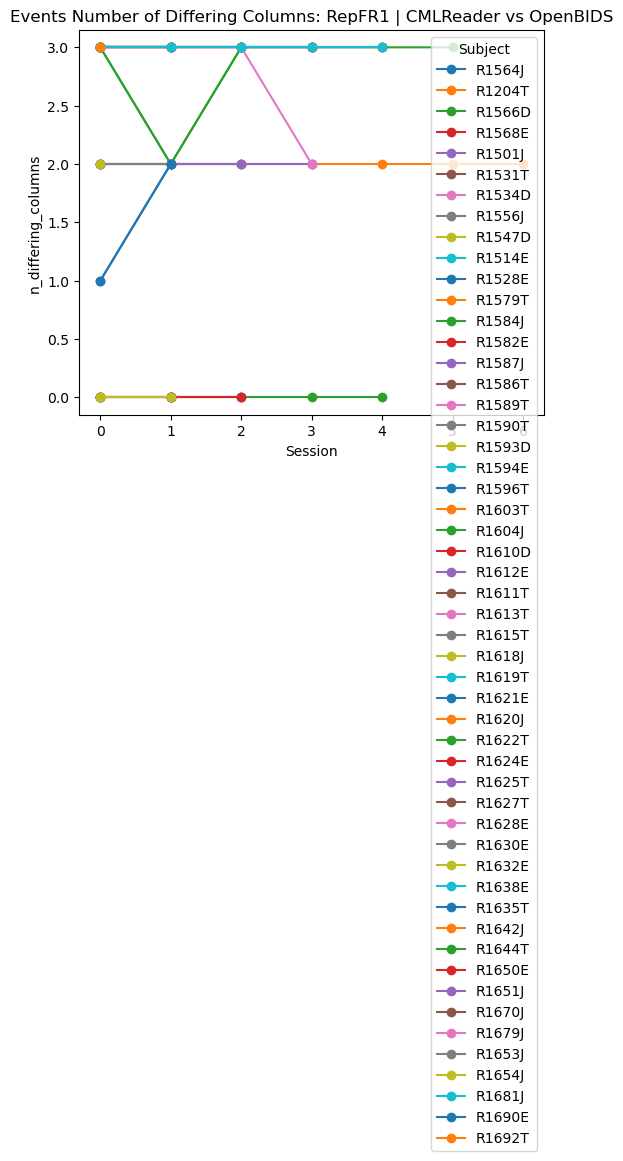

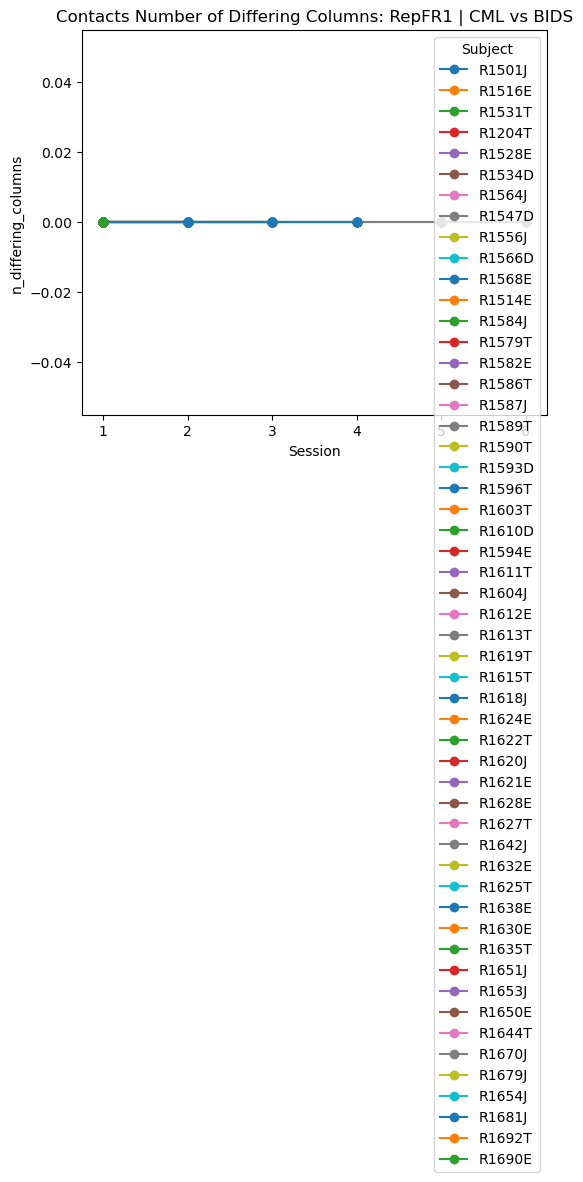

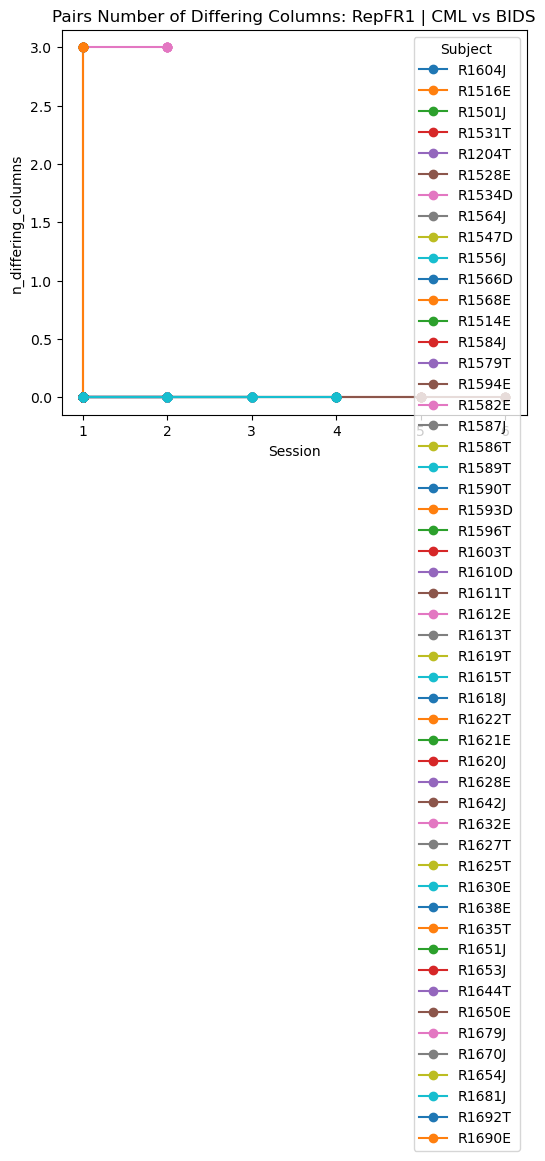

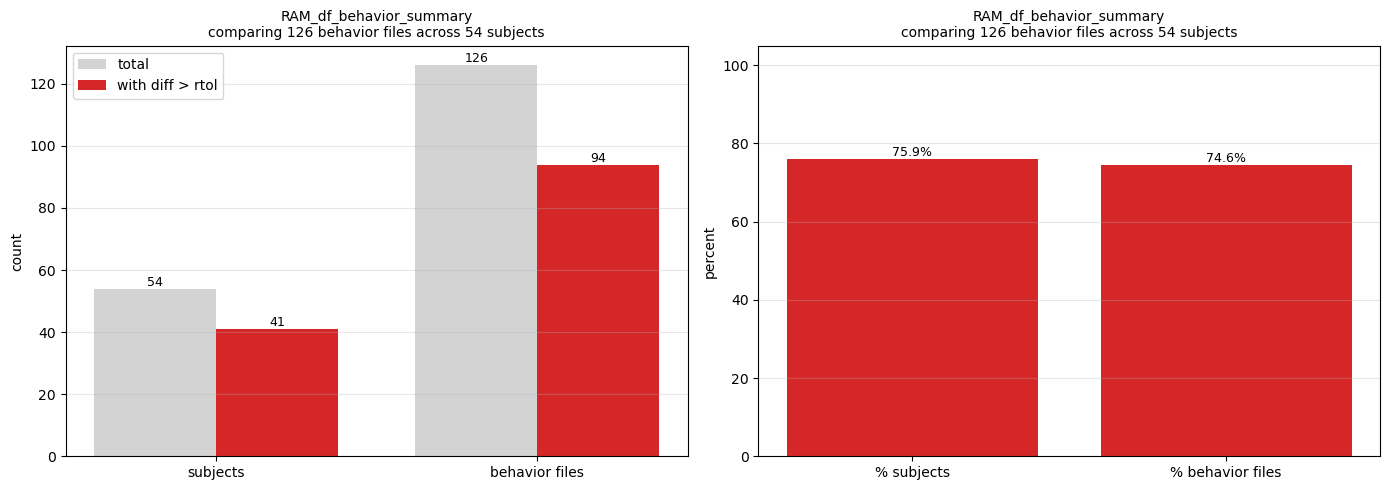

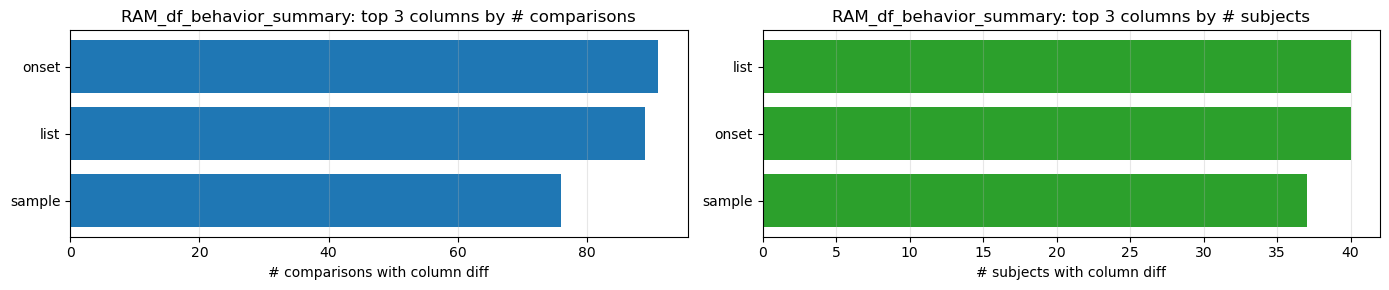

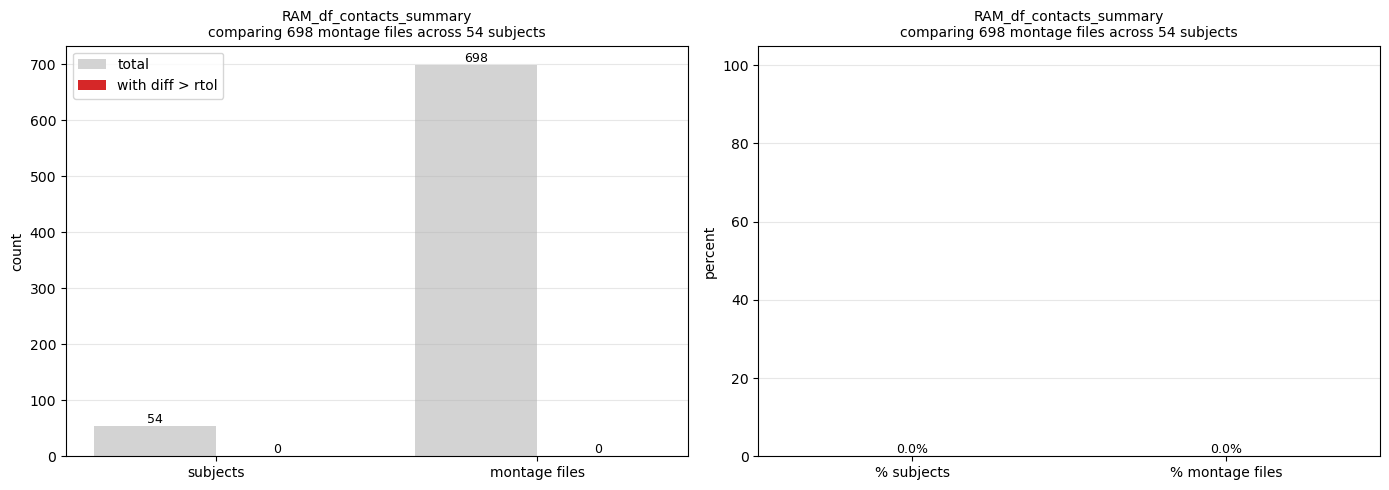

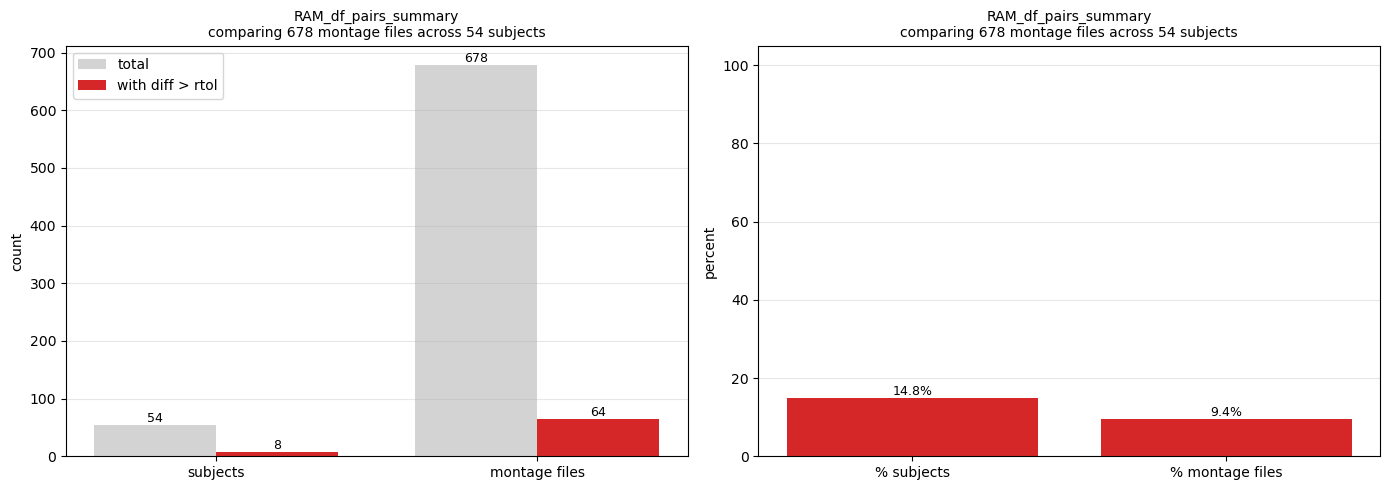

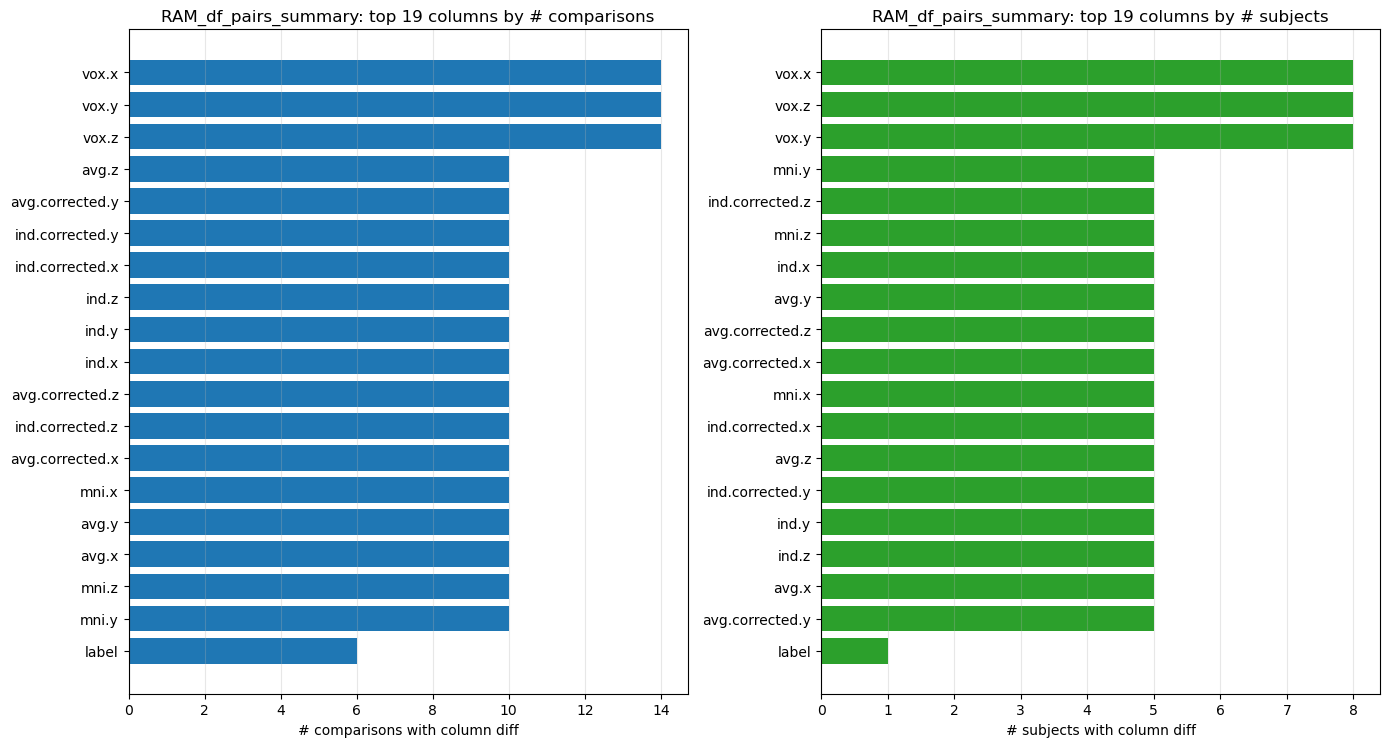

In [12]:
for k in ram_dfs.keys():
    if ram_dfs[k] is not None and "differing_columns" in ram_dfs[k].columns:
        ram_dfs[k]['n_differing_columns'] = ram_dfs[k]["differing_columns"].apply(_safe_col_len)

# --- Behavioral plots ---
if "df_behavior_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_behavior_summary"], "n_differing_columns", title="Events Number of Differing Columns")

if "df_contacts_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_contacts_summary"], "n_differing_columns", title="Contacts Number of Differing Columns")

if "df_pairs_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_pairs_summary"], "n_differing_columns", title="Pairs Number of Differing Columns")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
# Use df_ram (the BIDS data index for jobs) as ground truth for denominators.
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [13]:
FILE_CATEGORIES_RAM = [
    "df_epoch_summary", "df_epoch_time",
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM,ram_final)


Skipping df_epoch_summary (file not found: /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_epoch_summary_all.csv)
Skipping df_epoch_time (file not found: /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_epoch_time_all.csv)


In [14]:
# --- Helper: if summary has per-event rows, aggregate to one row per (subject, session, acquisition) ---
def aggregate_epoch_summary(df):
    """Keep only 'ALL' rows if present, otherwise average over event types."""
    if "event_type" in df.columns and "ALL" in df["event_type"].values:
        return df[df["event_type"] == "ALL"].copy()
    # Fallback: average numeric columns, keep first of non-numeric
    group_cols = ["subject", "experiment", "session", "comparison", "source_a", "source_b"]
    if "acquisition" in df.columns:
        group_cols.append("acquisition")
    group_cols = [c for c in group_cols if c in df.columns]
    return df.groupby(group_cols, as_index=False).mean(numeric_only=True)
# ram_dfs = aggregate_epoch_summary(ram_dfs[])
# --- Raw signal plots ---
if "df_epoch_summary" in ram_dfs:
    epoch_summary = aggregate_epoch_summary(ram_dfs["df_epoch_summary"])
    plot_comparison_results(epoch_summary, "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Epochs Mean Difference")
    plot_comparison_results(epoch_summary, "mse", col_label="MSE Epochs", title="Epochs MSE")
    plot_comparison_results(epoch_summary, "n_exact_diff_channels", title="Epochs Number of Differing EEG Channels (No Tolerance)")
    plot_comparison_results(epoch_summary, "n_close_diff_channels", title="Epochs Number of Differing EEG Channels (Tolerance)")

if "df_epoch_time" in ram_dfs:
    plot_comparison_results(ram_dfs["df_epoch_time"], "n_close_time_diff", col_label="Number of Events", title="Number of Events Time Different (No Tolerance)")
    plot_comparison_results(ram_dfs["df_epoch_time"], "mean_abs_time_diff","std_time_diff", col_label="Time (s)", title="Epoch Time Difference")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [15]:
FILE_CATEGORIES_RAM = [
    "df_digital_summary"
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM, ram_final)


df_digital_summary: loaded 234 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_digital_summary_all.csv


/home1/zrentala/eeg-validation/eeg_validation/plotting.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


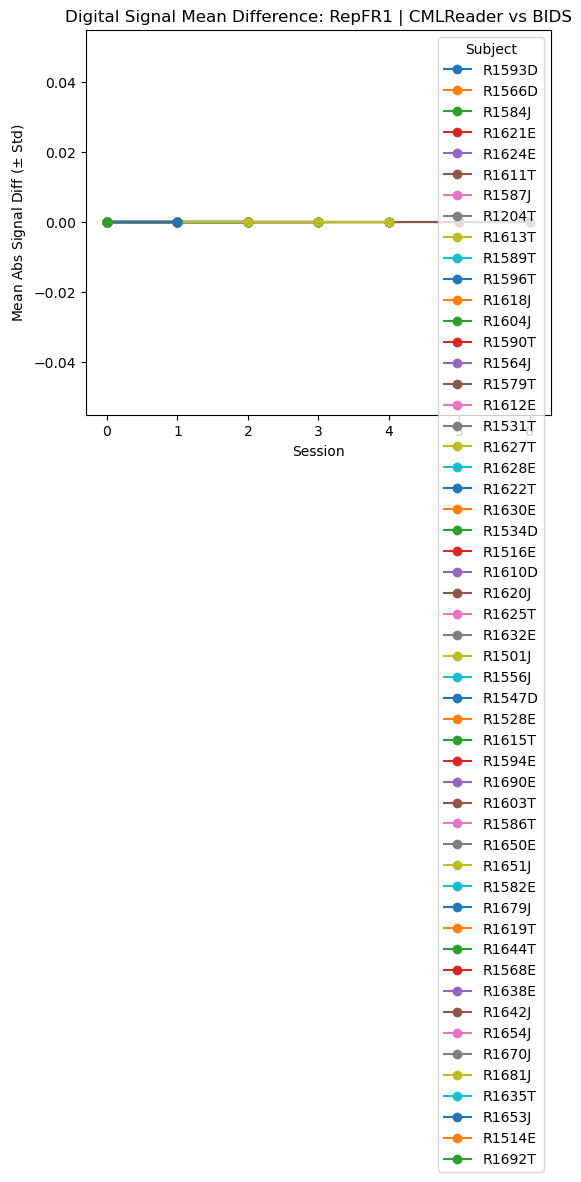

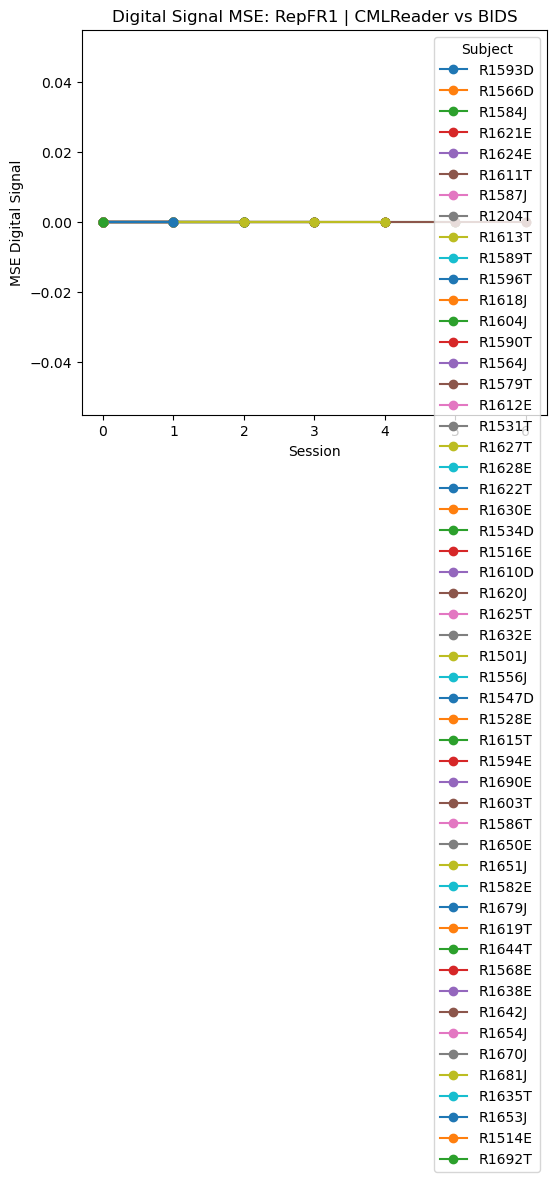

In [16]:
if "df_digital_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Digital Signal Mean Difference")
    plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "mse", col_label="MSE Digital Signal", title="Digital Signal MSE")
    # plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "n_exact_diff_channels", title="Raw Signal Number of Differing EEG Channels (No Tolerance)")
    # plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "n_close_diff_channels", title="Raw Signal Number of Differing EEG Channels (Tolerance)")
    
# --- New: per-pipeline summary stats + plots (saved to disk) ---
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [17]:
FILE_CATEGORIES_RAM = [
    "df_raw_summary", "df_raw_time",
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM, ram_final)


df_raw_summary: loaded 230 rows from /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_raw_summary_all.csv
Skipping df_raw_time (file not found: /home1/zrentala/eeg-validation/results/RepFR1_final_neurorad/df_raw_time_all.csv)


/home1/zrentala/eeg-validation/eeg_validation/plotting.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


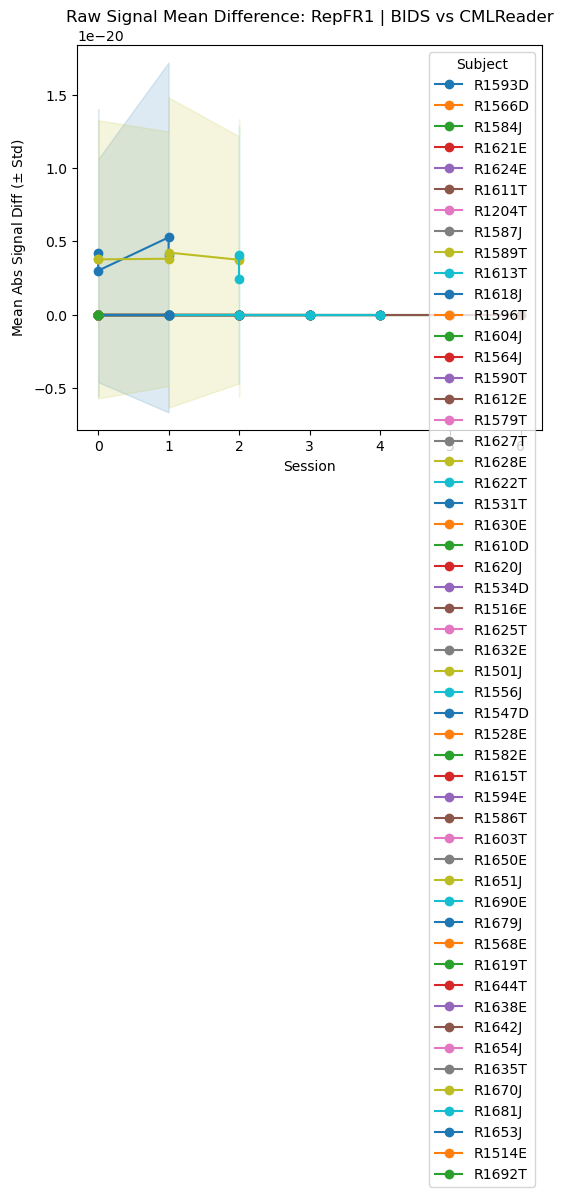

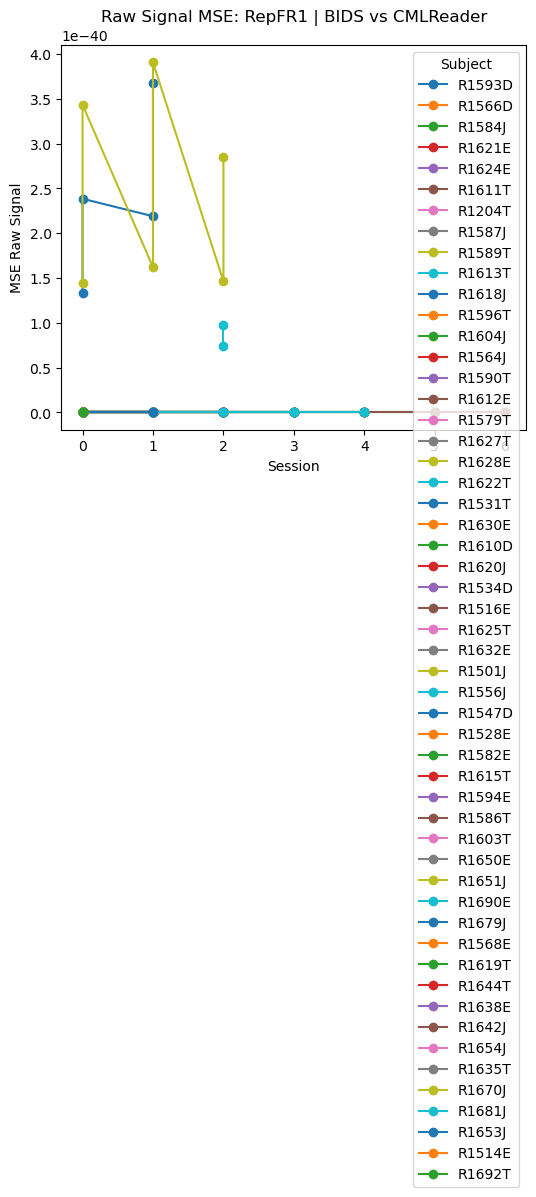

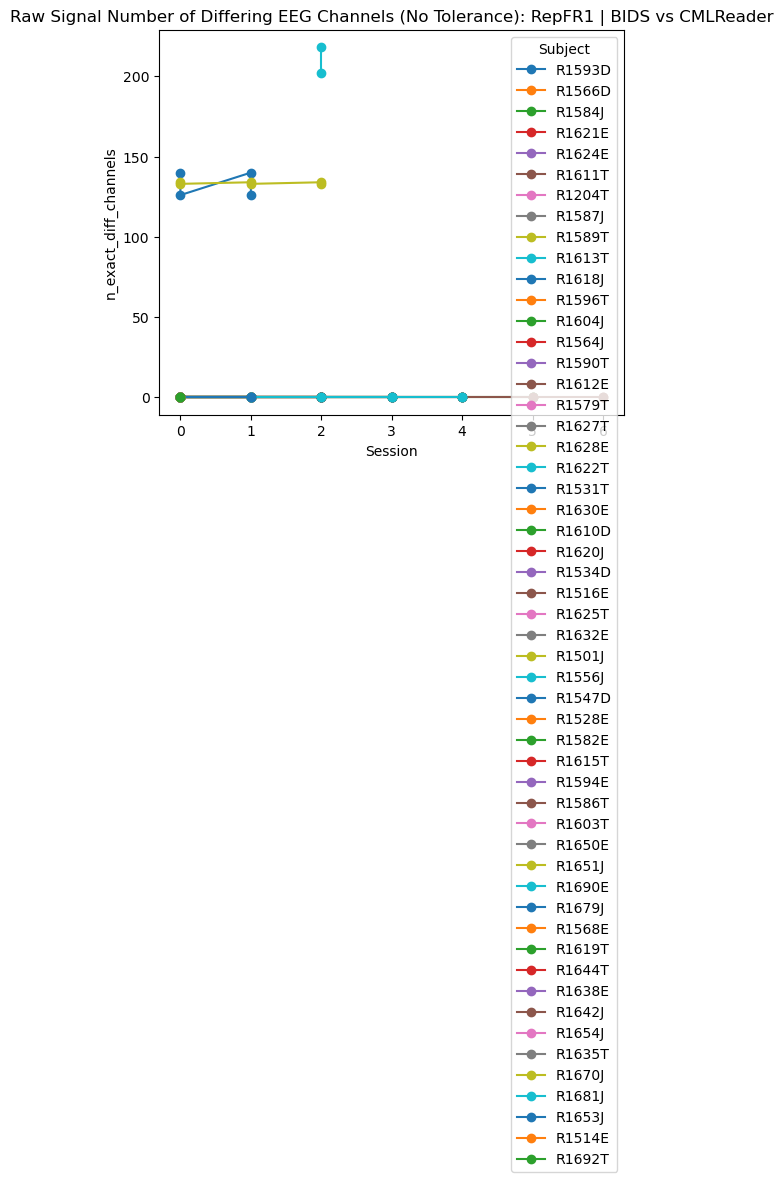

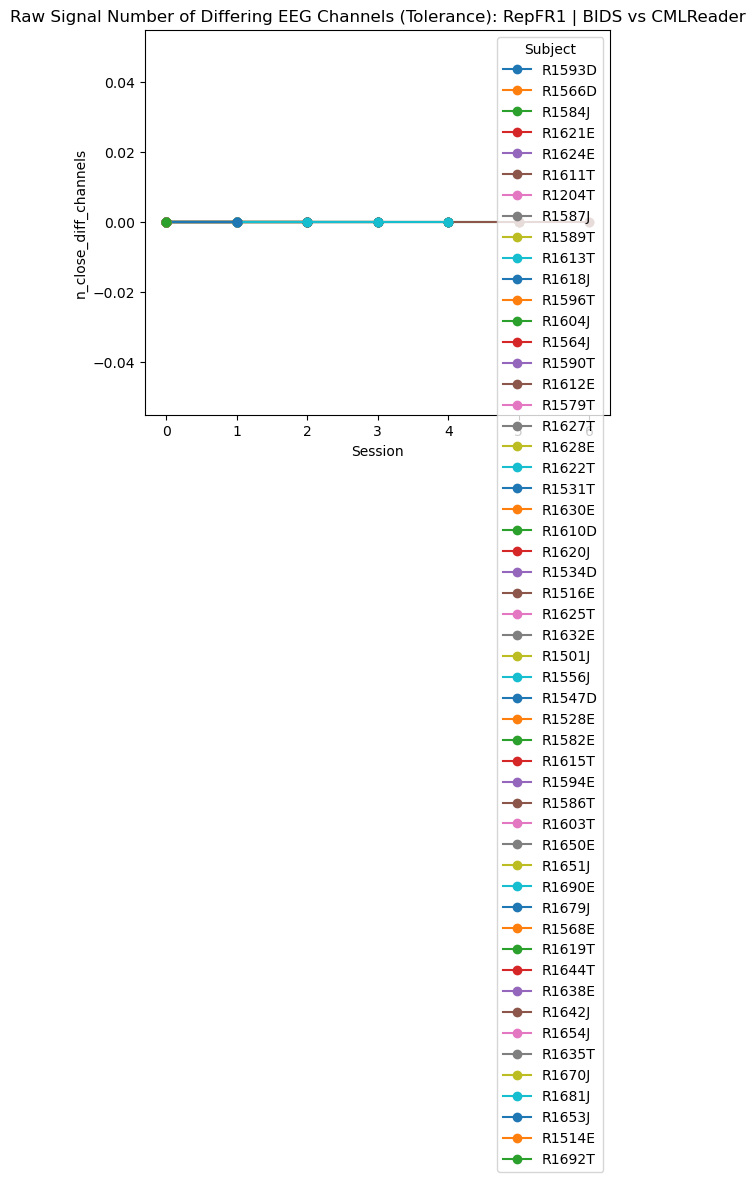

2026-05-04 18:57:21,984 - distributed.deploy.adaptive_core - INFO - Adaptive stop


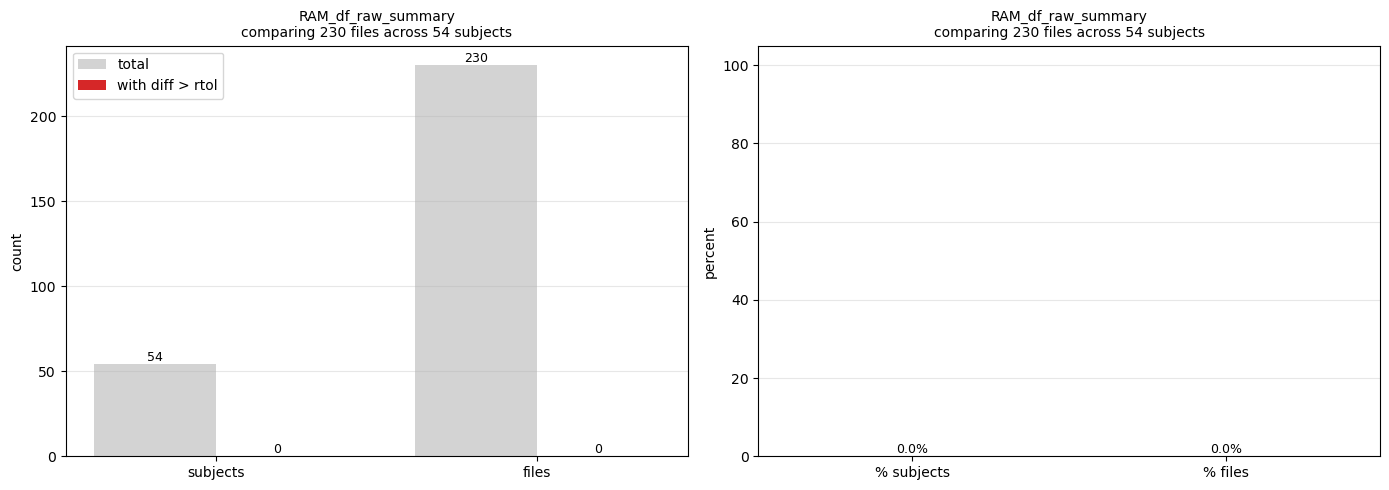

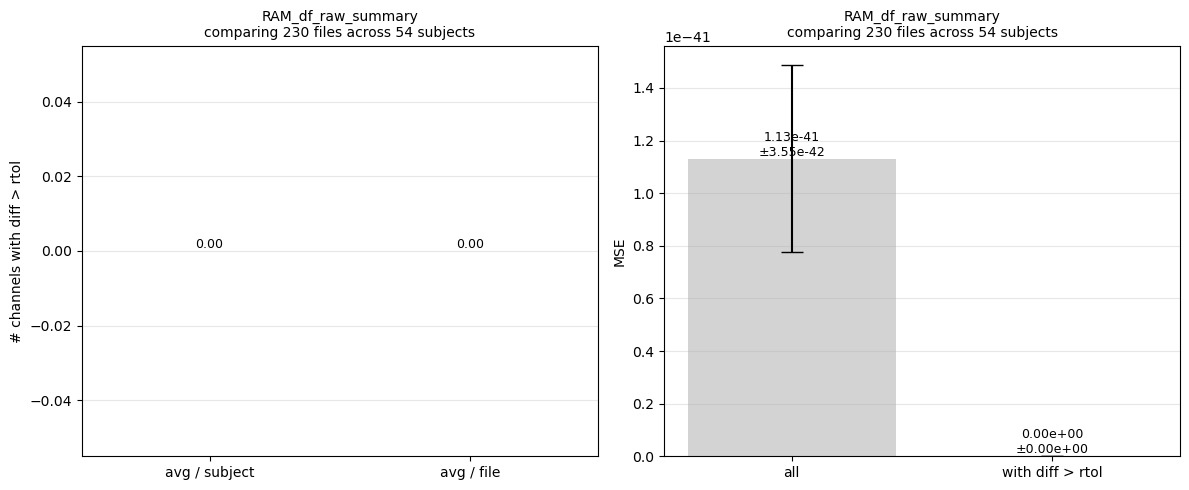

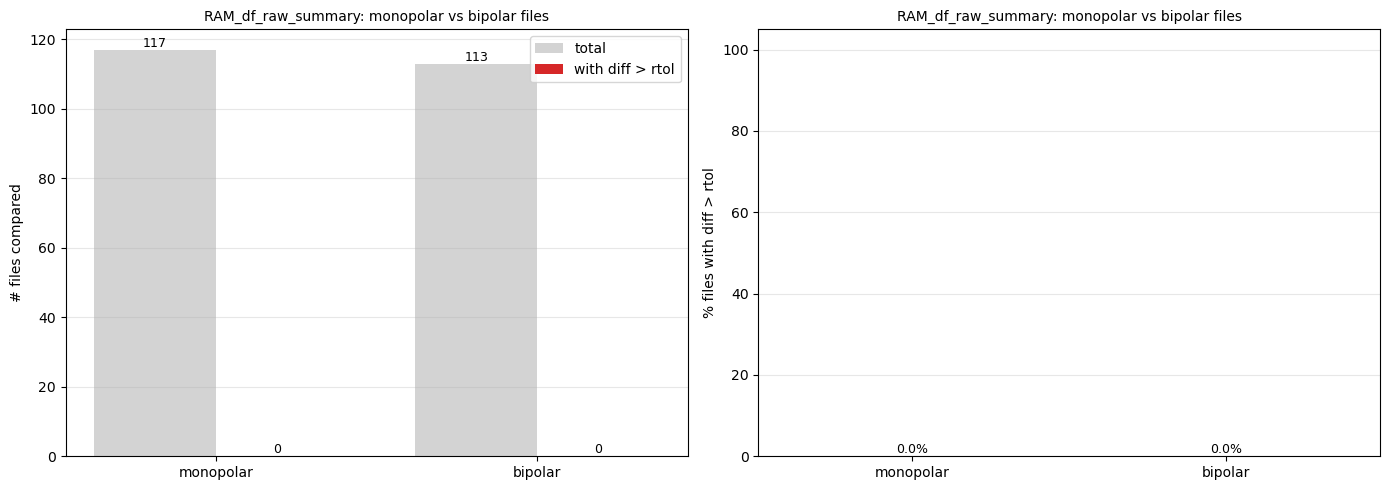

In [18]:
if "df_raw_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Raw Signal Mean Difference")
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "mse", col_label="MSE Raw Signal", title="Raw Signal MSE")
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "n_exact_diff_channels", title="Raw Signal Number of Differing EEG Channels (No Tolerance)")
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "n_close_diff_channels", title="Raw Signal Number of Differing EEG Channels (Tolerance)")
    
if "df_raw_time" in ram_dfs:
    # plot_comparison_results(ram_dfs["df_raw_time"], "n_close_time_diff", col_label="Number of Events", title="Number of Events Different (No Tolerance)")
    plot_comparison_results(ram_dfs["df_raw_time"], "mean_abs_time_diff","std_time_diff", col_label="Time (s)", title="Raw Time Difference")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [11]:
# ---- VFFR diagnostic: is the MSE caused by Status / EXG channels? ----
# Loads LTP229 VFFR session 0, runs the comparator three times:
#   (a) all channels (matches what RawSignalPipeline saves)
#   (b) drop the BioSemi `Status` channel
#   (c) also drop the EXG1..EXG8 auxiliary channels
# If (b) or (c) brings mse / max_abs_diff down by orders of magnitude,
# the per-session VFFR mse spread is driven by those channels and not by
# the `eeg_cml / self.conversion_to_v` step in raw_signal.py:49.

from eeg_validation.loaders.cml import load_cml_eeg_raw
from eeg_validation.loaders.bids import load_bids_raw, raw_to_xarray, get_reader
from eeg_validation.comparators.signal import SignalComparator

SUB, EXP, SESS = "LTP229", "VFFR", 0

# --- Load CML side (same call the pipeline uses) ---
eeg_cml = load_cml_eeg_raw(SUB, EXP, SESS)
print(f"CML  shape={eeg_cml.shape}  dtype={eeg_cml.dtype}")
print(f"     min={float(eeg_cml.min()):.6g}  max={float(eeg_cml.max()):.6g}  mean={float(eeg_cml.mean()):.6g}")

# --- Load BIDS side via the same reader the pipeline uses ---
reader = get_reader(SUB, EXP, SESS, "/data/LTP_BIDS/VFFR")
raw_bids = load_bids_raw(reader, acquisition=None)
raw_bids.load_data()
eeg_bids = raw_to_xarray(raw_bids, convert_ms=True)
print(f"BIDS shape={eeg_bids.shape}  dtype={eeg_bids.values.dtype}")
print(f"     min={float(eeg_bids.min()):.6g}  max={float(eeg_bids.max()):.6g}  mean={float(eeg_bids.mean()):.6g}")
print()

# --- Apply the same /conversion_to_v default the pipeline applies for VFFR ---
# (VFFR is not in system_1_unit_conversions.csv, so the pipeline falls back to 1e6.)
eeg_cml = eeg_cml / 1e6
print(f"After /1e6: CML min={float(eeg_cml.min()):.6g}  max={float(eeg_cml.max()):.6g}")
print()

# --- Run the comparator three ways ---
def _drop(da, names):
    keep = [c for c in da.channel.values if c not in set(names)]
    return da.sel(channel=keep)

def _run(label, a, b):
    res = SignalComparator().compare(
        a, b, label_a="BIDS", label_b="CMLReader",
        subject=SUB, experiment=EXP, session=SESS, acquisition="scalp",
    )
    s = res.df_summary.iloc[0]
    print(f"  {label:25s}  n_ch={int(s['n_common_channels']):3d}  "
          f"mean_abs_diff={s['mean_abs_diff']:.4g}  "
          f"max_abs_diff={s['max_abs_diff']:.4g}  "
          f"std_diff={s['std_diff']:.4g}  "
          f"mse={s['mse']:.4g}")
    return s

print("=== Comparator output, three drop levels ===")
_run("(a) all channels",                 eeg_bids, eeg_cml)

drop_status = ["Status"]
_run("(b) drop Status",
     _drop(eeg_bids, drop_status), _drop(eeg_cml, drop_status))

drop_status_exg = ["Status"] + [f"EXG{i}" for i in range(1, 9)]
_run("(c) drop Status + EXG1-8",
     _drop(eeg_bids, drop_status_exg), _drop(eeg_cml, drop_status_exg))


Extracting BDF parameters from /protocols/ltp/subjects/LTP229/experiments/VFFR/sessions/0/ephys/current_processed/LTP229_session_0.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9539583  =      0.000 ...  4658.000 secs...


KeyboardInterrupt: 